In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv("https://raw.githubusercontent.com/abaffa/INF1038/main/dataset/expectativa.csv")

# Medidas de Associação

### Covariância

In [2]:
#since pandas 2.0.0 numeric_only=True
data.cov(numeric_only=True)

,year,pop,lifeExp,gdpPercap
year,2.980916e+02,1.508584e+08,9.714919e+01,3.868776e+04
pop,1.508584e+08,1.126950e+16,8.907024e+07,-2.678859e+10
lifeExp,9.714919e+01,8.907024e+07,1.668517e+02,7.432320e+04
gdpPercap,3.868776e+04,-2.678859e+10,7.432320e+04,9.716941e+07


In [3]:
data.gdpPercap.cov(data.lifeExp)

74323.19574798805

In [4]:
np.cov(data.gdpPercap, data.lifeExp)

array([[9.71694101e+07, 7.43231957e+04],
       [7.43231957e+04, 1.66851664e+02]])

### Correlação

Peason

In [5]:
#since pandas 2.0.0 numeric_only=True
data.corr(numeric_only=True)

,year,pop,lifeExp,gdpPercap
year,1.000000,0.082308,0.435611,0.227318
pop,0.082308,1.000000,0.064955,-0.025600
lifeExp,0.435611,0.064955,1.000000,0.583706
gdpPercap,0.227318,-0.025600,0.583706,1.000000


In [6]:
data.gdpPercap.corr(data.lifeExp)

0.5837062198659948

In [7]:
np.corrcoef(data.gdpPercap, data.lifeExp)

array([[1.        , 0.58370622],
       [0.58370622, 1.        ]])

In [8]:
from scipy import stats
gdpPercap = data.gdpPercap.values
life_exp = data.lifeExp.values

print(stats.pearsonr(gdpPercap,life_exp))

PearsonRResult(statistic=0.5837062198659948, pvalue=3.5657242410536764e-156)


Spearman

In [9]:
print(stats.spearmanr(gdpPercap,life_exp))

SignificanceResult(statistic=0.8264711811970715, pvalue=0.0)


Kendall Tau

In [10]:
print(stats.kendalltau(gdpPercap,life_exp))

SignificanceResult(statistic=0.6369106595644447, pvalue=0.0)


# Análise Multivariada

![analise_exploratoria_de_dados.png](https://github.com/abaffa/INF1038/blob/main/images/analise_exploratoria_de_dados.png?raw=1)

### Matriz de Correlação

<Axes: >

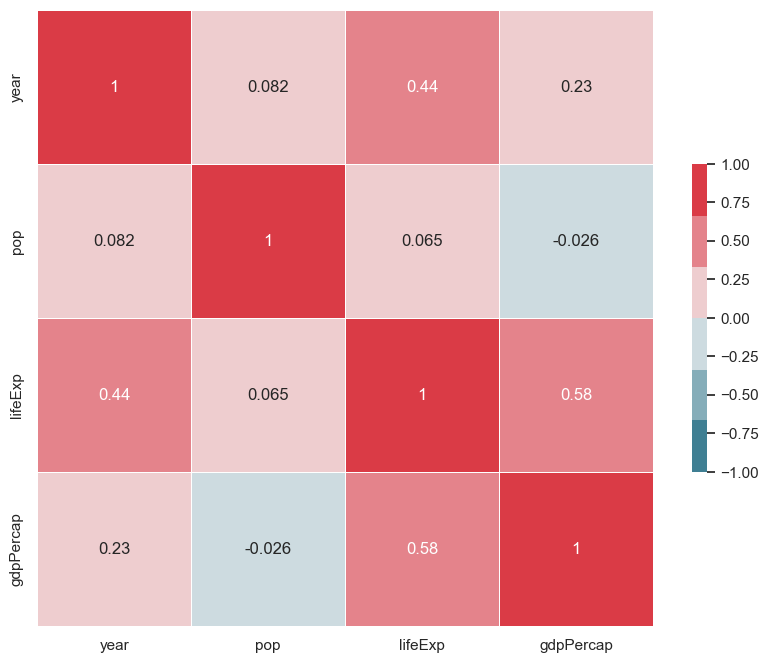

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="darkgrid")

f, ax = plt.subplots(figsize=(10, 8))
corr = data.corr(numeric_only=True)

cmap = sns.diverging_palette(220, 10)

sns.heatmap(corr, annot=True, cmap=cmap, vmax=1, vmin=-1, center=0, square=True,
            linewidth=.5,cbar_kws={"shrink":.5})


Simplificando visualização da Matriz de correlação

<Axes: >

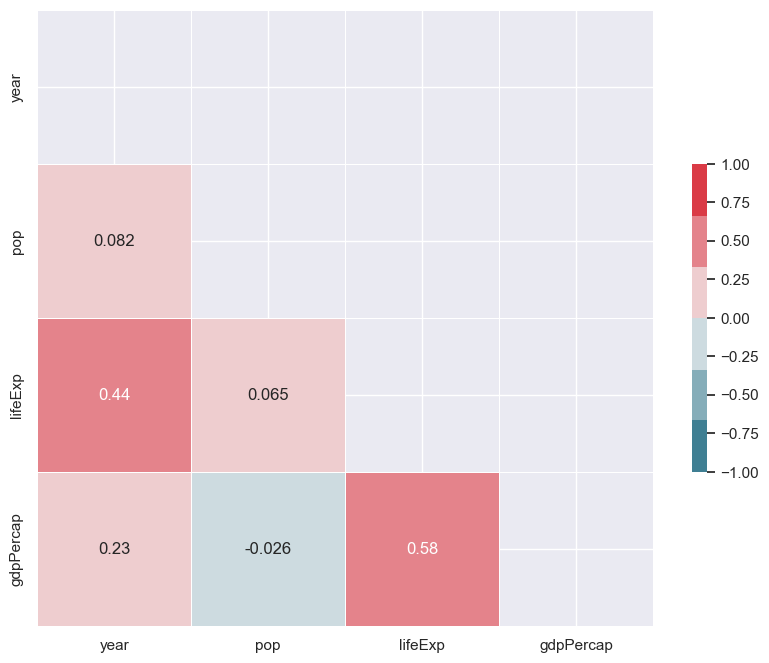

In [12]:
sns.set(style="darkgrid")

f, ax = plt.subplots(figsize=(10, 8))

corr = data.select_dtypes('number').corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(220, 10)

sns.heatmap(corr, mask=mask, annot=True, cmap=cmap,
            vmax=1, vmin=-1, center=0, square=True,
            linewidth=.5,cbar_kws={"shrink":.5})

In [13]:
data.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


In [14]:
from scipy import stats
df = data
temp_df = df[['continent','lifeExp']].groupby(['continent'])
stats.f_oneway(temp_df.get_group('Americas')['lifeExp'],temp_df.get_group('Europe')['lifeExp'])

F_onewayResult(statistic=153.95713722112586, pvalue=6.469761828411885e-32)

### Scatterplot

Text(0, 0.5, 'Frequência')

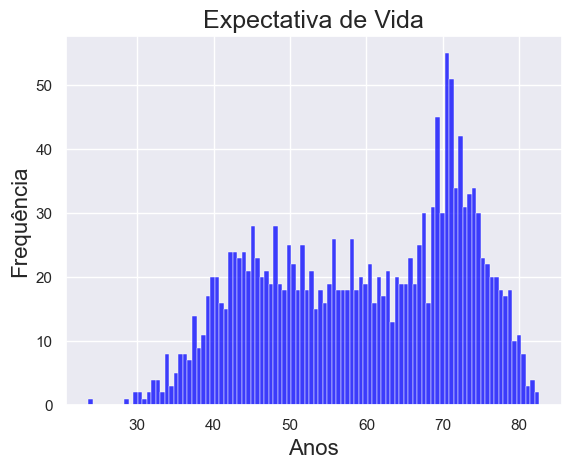

In [15]:
hplot = sns.histplot(data['lifeExp'], kde=False, color='blue', bins=100)
plt.title('Expectativa de Vida', fontsize=18)
plt.xlabel('Anos', fontsize=16)
plt.ylabel('Frequência', fontsize=16)

Text(0, 0.5, 'Valores PIB')

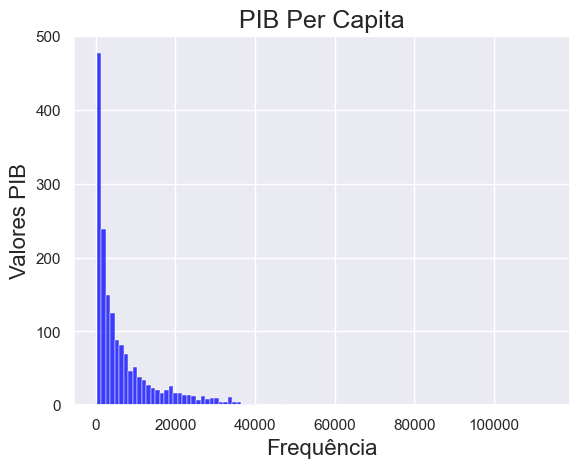

In [16]:
hplot = sns.histplot(data['gdpPercap'], kde=False, color='blue', bins=100)
plt.title('PIB Per Capita', fontsize=18)
plt.xlabel('Frequência', fontsize=16)
plt.ylabel('Valores PIB', fontsize=16)

In [17]:
data[['lifeExp','gdpPercap']]

,lifeExp,gdpPercap
0,28.801,779.445314
1,30.332,820.853030
2,31.997,853.100710
3,34.020,836.197138
4,36.088,739.981106
...,...,...
1699,62.351,706.157306
1700,60.377,693.420786
1701,46.809,792.449960
1702,39.989,672.038623


Text(0.5, 0, 'Expectativa de Vida')

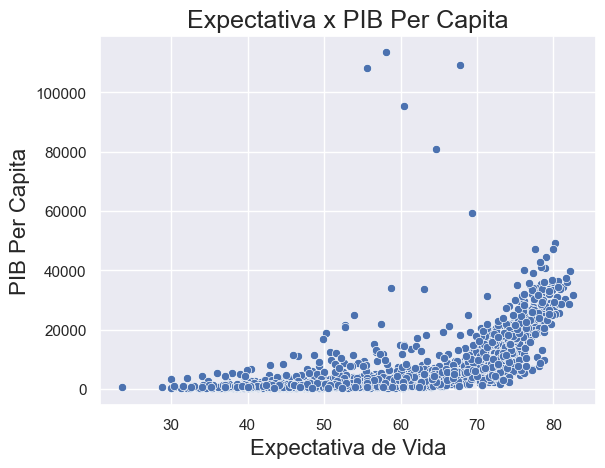

In [18]:
sns.scatterplot(data=data,x='lifeExp',y='gdpPercap')
plt.title('Expectativa x PIB Per Capita', fontsize=18)
plt.ylabel('PIB Per Capita', fontsize=16)
plt.xlabel('Expectativa de Vida', fontsize=16)

Escala Logarítimica

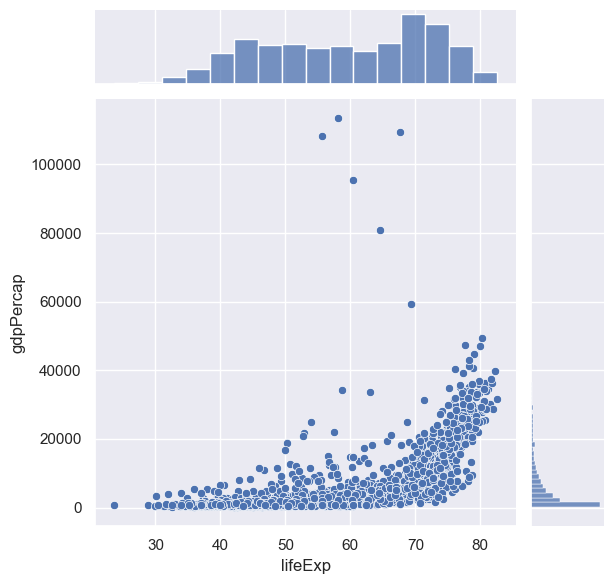

In [19]:
sns.jointplot(
    data=df,
    x='lifeExp',
    y='gdpPercap'
)

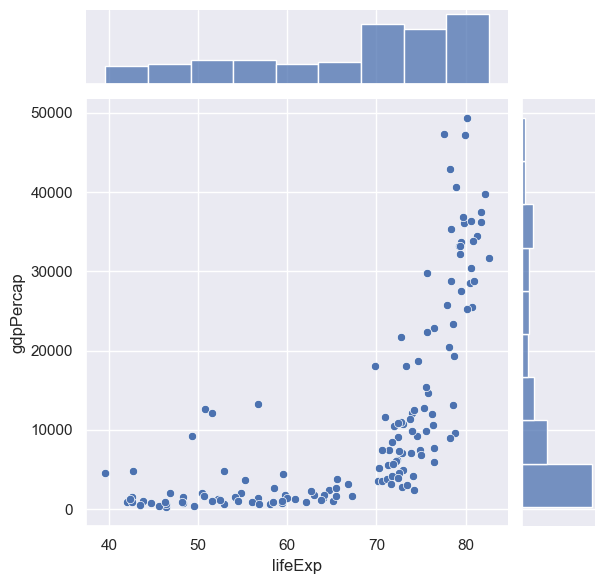

In [20]:
sns.jointplot(
    data=df[df.year==2007],
    x='lifeExp',
    y='gdpPercap'
)

Text(0.5, 0, 'Expectativa de Vida')

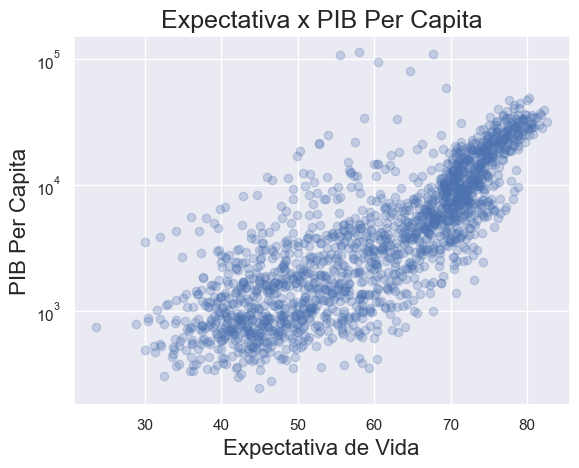

In [21]:
splot = sns.regplot(x="lifeExp", y="gdpPercap",
                    data=data,
                    scatter_kws={'alpha':0.25},
                    fit_reg=False)

splot.set(yscale="log")

plt.title('Expectativa x PIB Per Capita', fontsize=18)
plt.ylabel('PIB Per Capita', fontsize=16)
plt.xlabel('Expectativa de Vida', fontsize=16)

Text(0.5, 0, 'Expectativa de Vida')

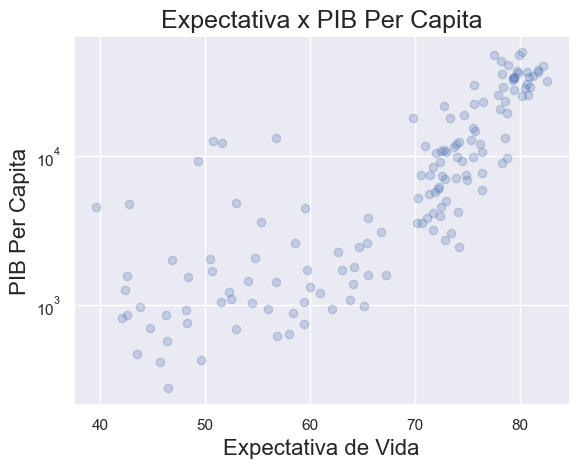

In [22]:
splot = sns.regplot(x="lifeExp", y="gdpPercap",
                    data=data[data.year==2007],
                    scatter_kws={'alpha':0.25},
                    fit_reg=False)

splot.set(yscale="log")

plt.title('Expectativa x PIB Per Capita', fontsize=18)
plt.ylabel('PIB Per Capita', fontsize=16)
plt.xlabel('Expectativa de Vida', fontsize=16)

Agrupando os dados por Continente

Text(0.5, 0, 'Expectativa de Vida')

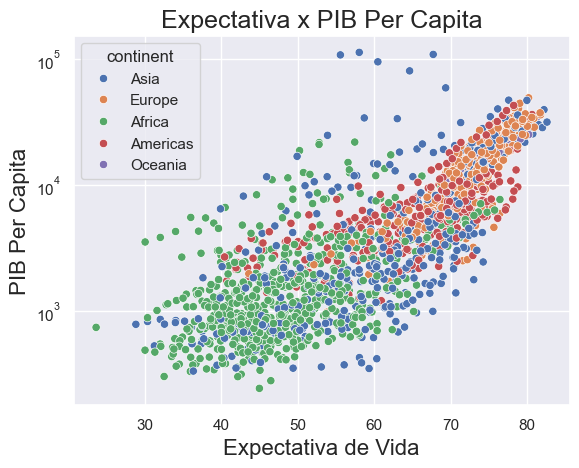

In [23]:
splot = sns.scatterplot(x="lifeExp", y="gdpPercap",
                    data=data, hue="continent")
splot.set(yscale="log")
plt.title('Expectativa x PIB Per Capita', fontsize=18)
plt.ylabel('PIB Per Capita', fontsize=16)
plt.xlabel('Expectativa de Vida', fontsize=16)

Text(0.5, 0, 'Expectativa de Vida')

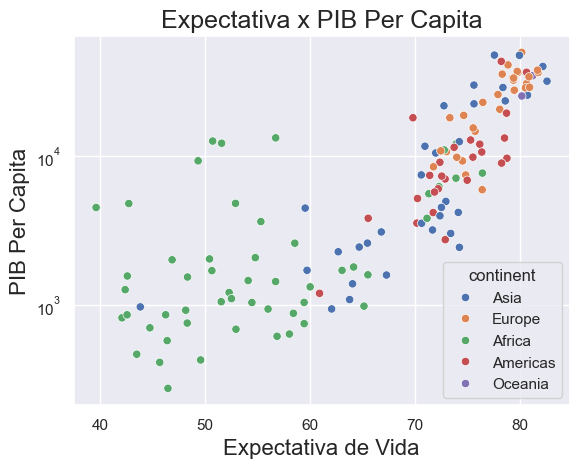

In [24]:
splot = sns.scatterplot(x="lifeExp", y="gdpPercap",
                    data=data[data.year==2007], hue="continent")
splot.set(yscale="log")
plt.title('Expectativa x PIB Per Capita', fontsize=18)
plt.ylabel('PIB Per Capita', fontsize=16)
plt.xlabel('Expectativa de Vida', fontsize=16)

Onde estava a Oceania?

(200, 150000)

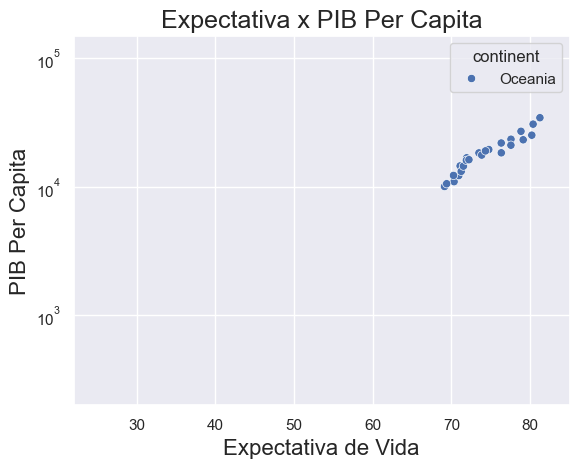

In [25]:
df=data[data.continent.isin(['Oceania'])]
splot = sns.scatterplot(x="lifeExp", y="gdpPercap",
                    data=df, hue="continent")
splot.set(yscale="log")
plt.title('Expectativa x PIB Per Capita', fontsize=18)
plt.ylabel('PIB Per Capita', fontsize=16)
plt.xlabel('Expectativa de Vida', fontsize=16)
splot.set_xlim(22,85)
splot.set_ylim(200,150000)

### Pairplot

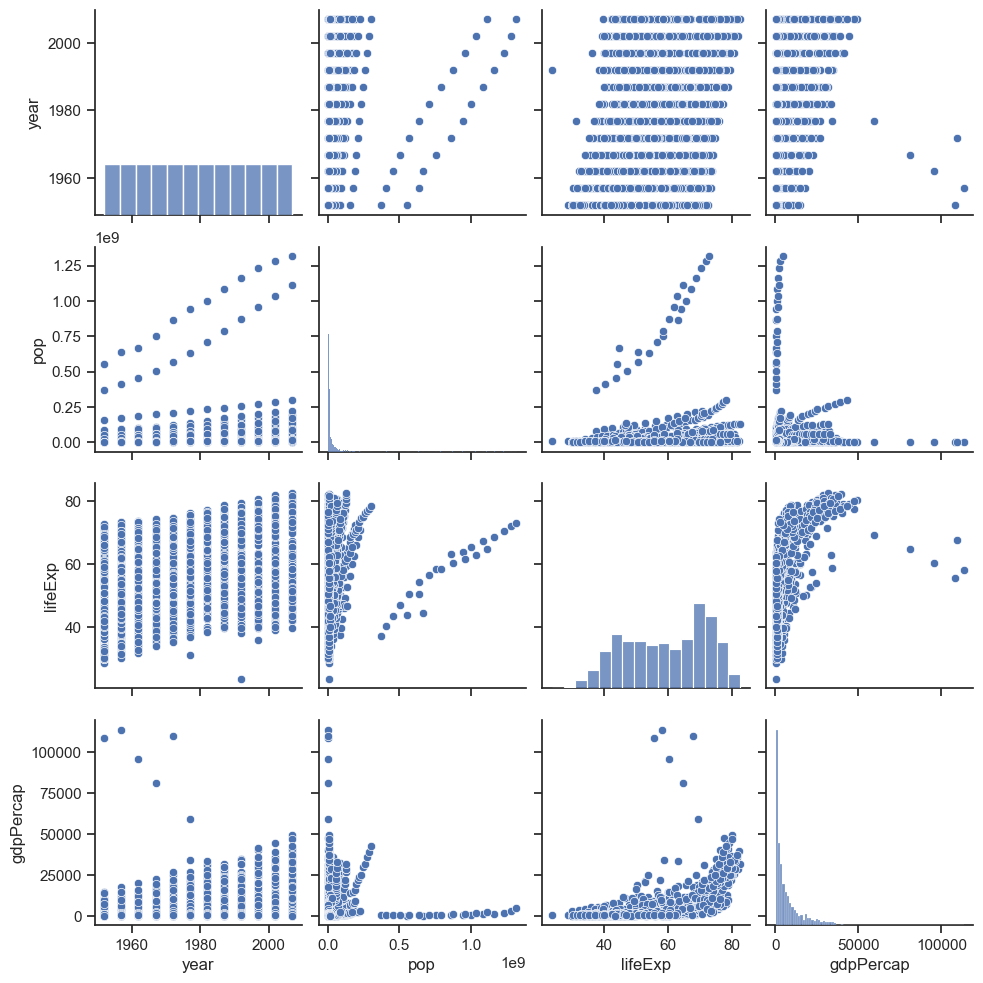

In [26]:
sns.set(style="ticks", color_codes=True)
sns.pairplot(data)

Exibindo a distribuição das variáveis

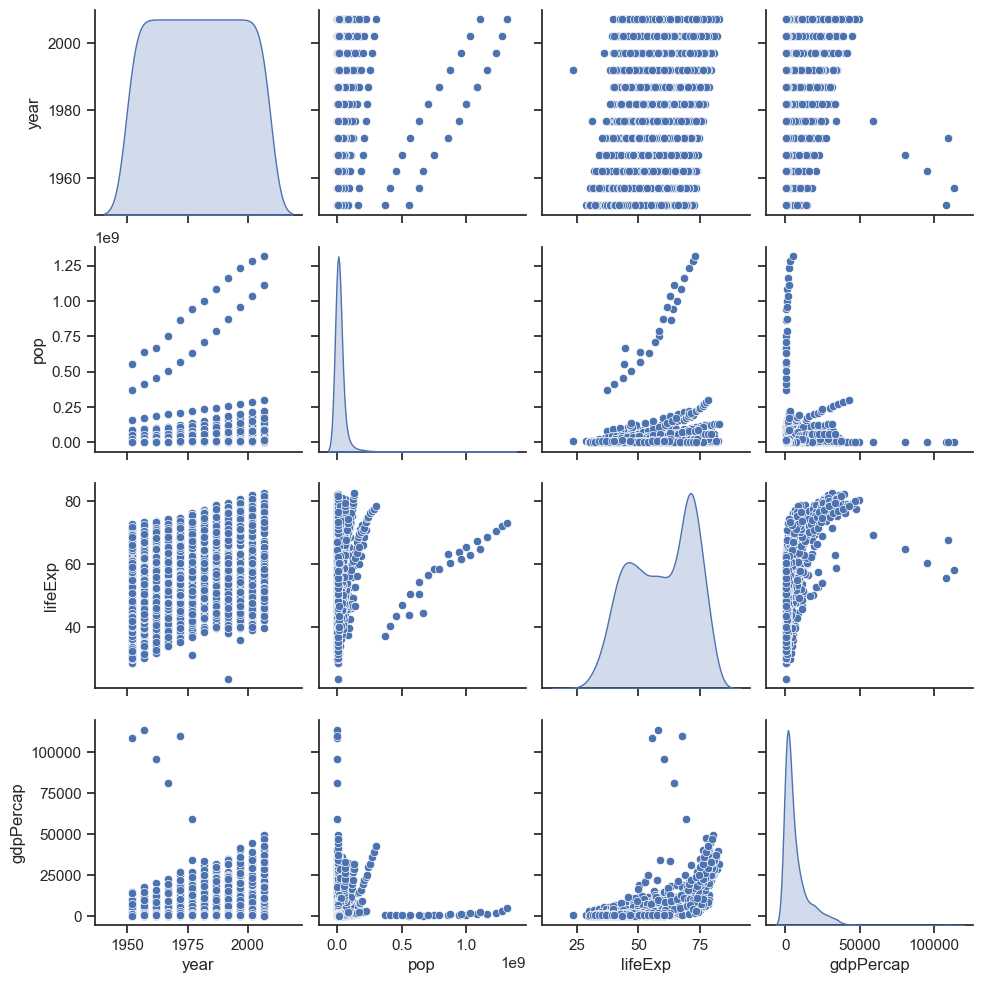

In [27]:
sns.pairplot(data, diag_kind="kde")

Exibindo as regressões das correlações

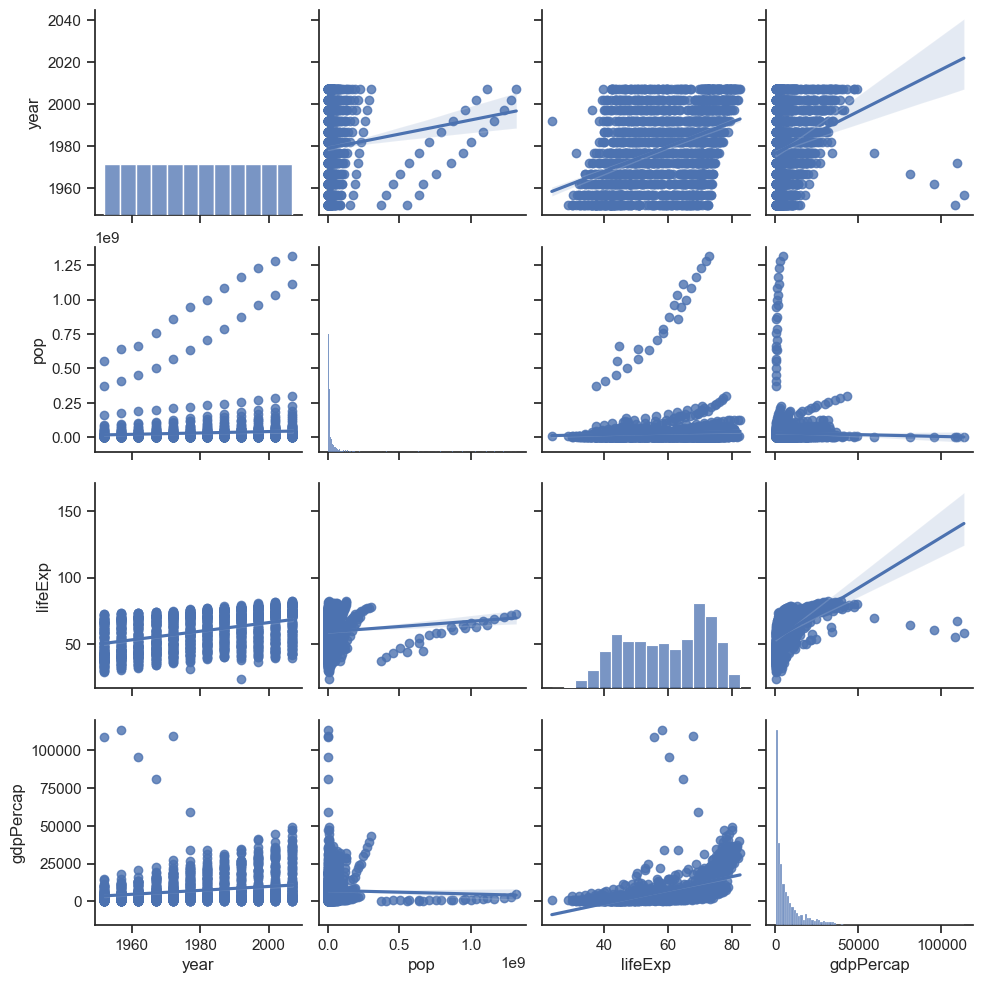

In [28]:
sns.pairplot(data, kind="reg")

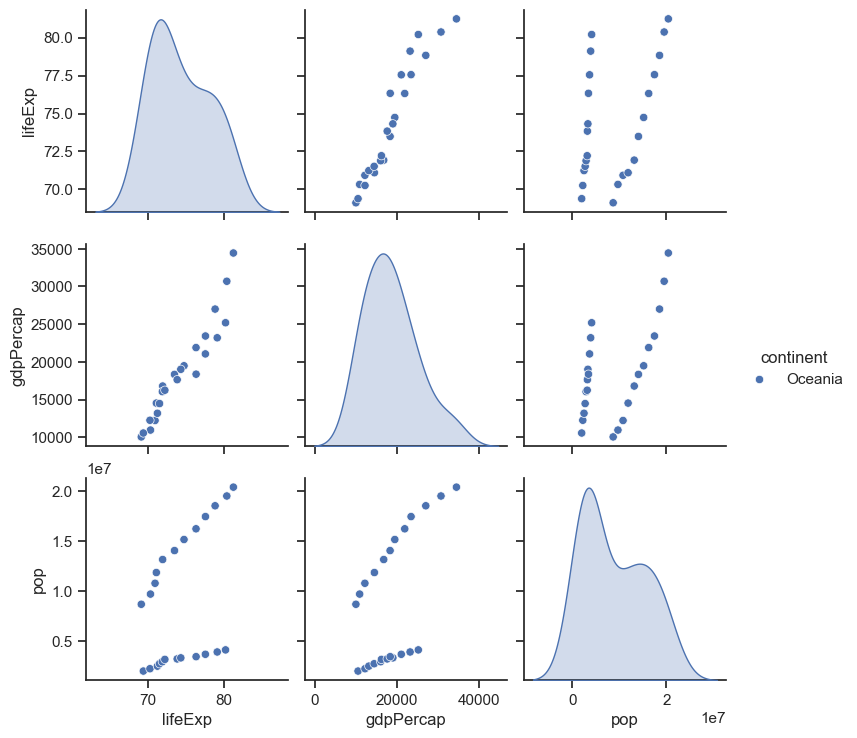

In [29]:
sns.pairplot(
    df,
    vars=['lifeExp', 'gdpPercap', 'pop'],
    hue='continent'
)

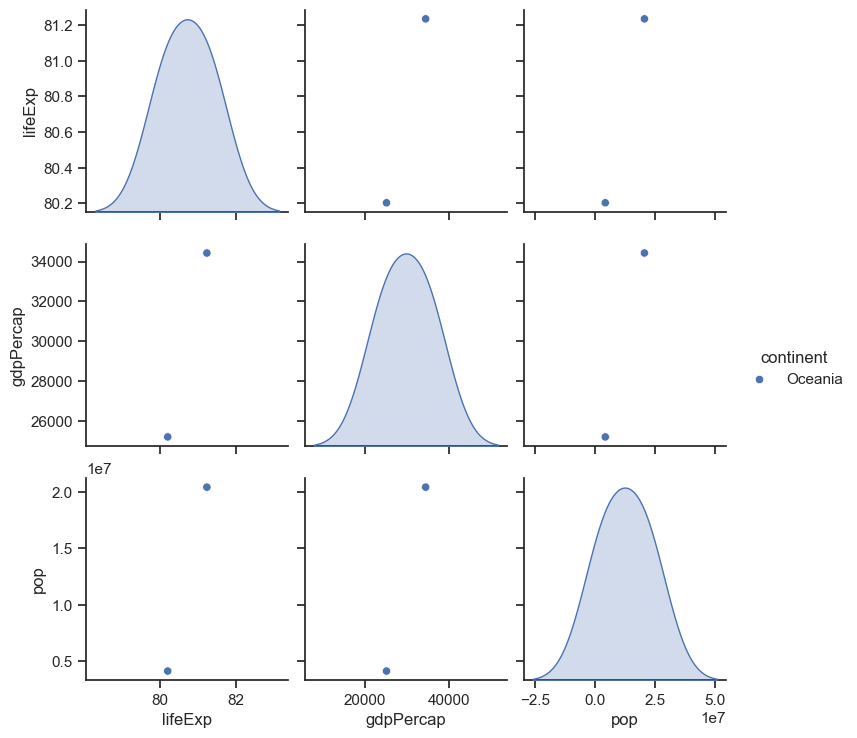

In [30]:
sns.pairplot(
    df[df.year==2007],
    vars=['lifeExp', 'gdpPercap', 'pop'],
    hue='continent'
)

### Boxplot

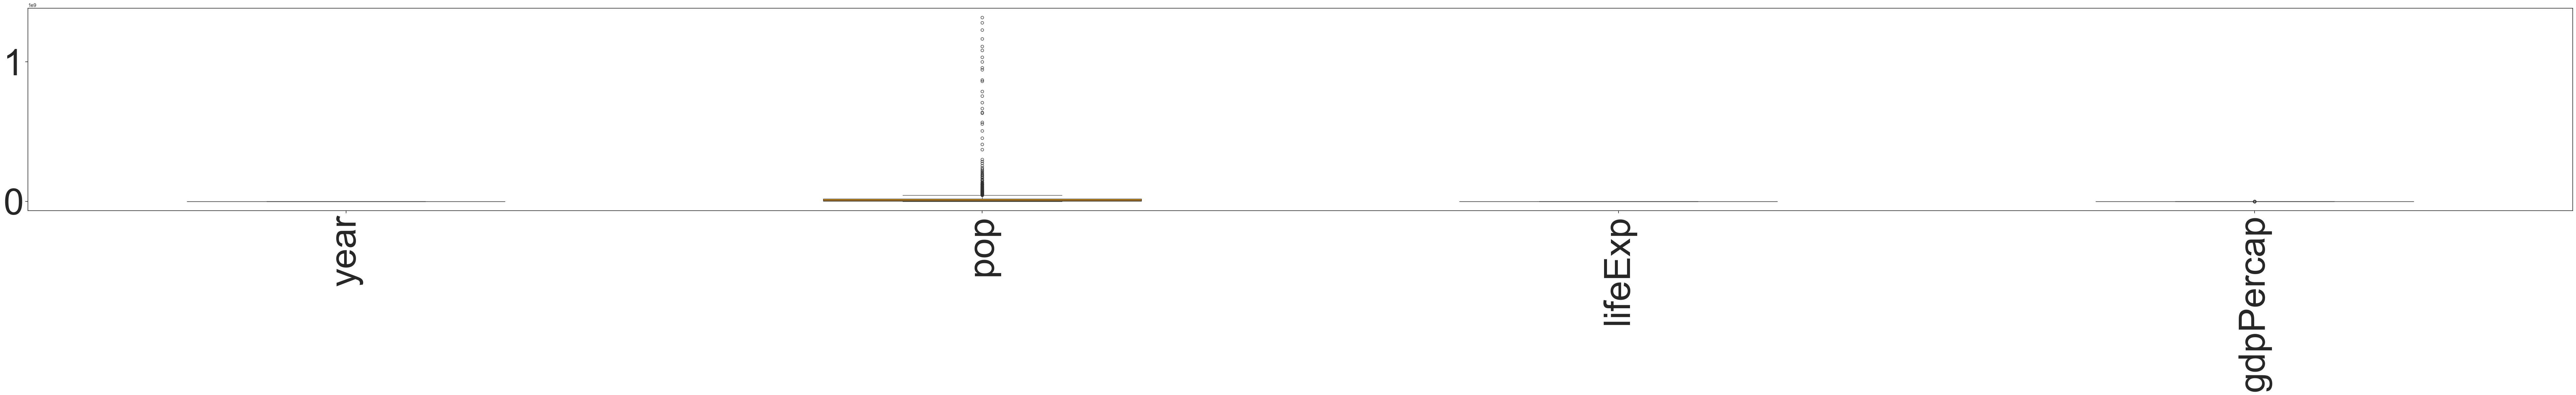

In [31]:
import seaborn as sns
f, ax = plt.subplots(figsize=(100, 8))
bp = sns.boxplot(data=data, width=0.5, palette="colorblind")
plt.setp(bp.get_xticklabels(), rotation=90)
bp.tick_params(labelsize=80)

### Ternário

In [32]:
#!pip install python-ternary
import ternary

def plot_ternario(title, labels,points,cor, endmembers):
    figure, tax = ternary.figure(scale=100)
    figure.set_size_inches(10, 10)
    tax.set_title(title, fontsize=15)
    tax.boundary(linewidth=2.0)
    tax.gridlines(multiple=10, color="blue")

    cb_kwargs = {"shrink" : 0.6,
                 "orientation" : "horizontal",
                 "fraction" : 0.1,
                 "pad" : 0.05,
                 "aspect" : 30}
    i = 0
    for label_ in labels:
        points_ = points[i]
        cor_    = cor[i]
        i = i + 1
        tax.scatter(points=points_,marker='s',edgecolor='k',s=40,linewidths=0.5, c=cor_,
                label=label_,vmin=0,vmax=100, cb_kwargs=cb_kwargs,zorder=3)

    tax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    tax.ticks(axis='lbr', linewidth=1, multiple=5)

    fontsize = 15
    tax.bottom_axis_label(endmembers[0], fontsize=fontsize)
    tax.right_axis_label(endmembers[1], fontsize=fontsize)
    tax.left_axis_label(endmembers[2], fontsize=fontsize)

    tax.get_axes().axis('off')
    tax.clear_matplotlib_ticks()

    tax.show()

D:\Backup\OneDrive - puc-rio.br\Jupyter\venv\lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


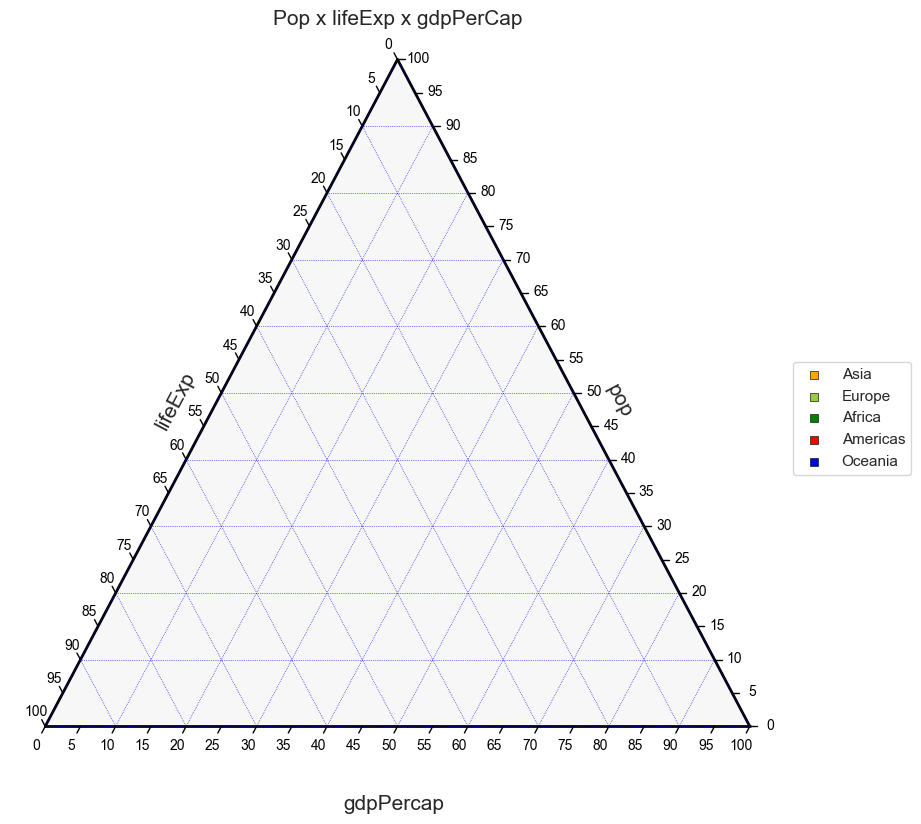

In [33]:
df = data[data.year == 2007]

label_pre = data["continent"].unique().tolist()

points = []
for label in label_pre:
    mask = df['continent'] == label
    pos = np.flatnonzero(mask)
    dataf = df.iloc[pos]
    endmembers = ['gdpPercap','pop','lifeExp']
    points_ = dataf[endmembers].values
    points.append(points_)

colors = ['orange', 'yellowgreen', 'green','red', 'blue']
plot_ternario("Pop x lifeExp x gdpPerCap",label_pre,points,colors,endmembers)

# Transformações de Dados

### Alisamento

<Axes: xlabel='continent', ylabel='lifeExp'>

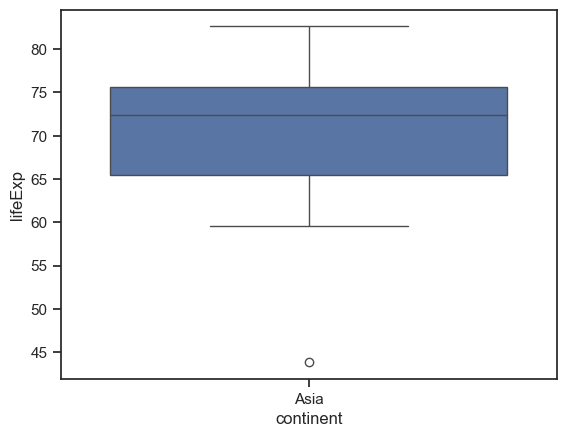

In [34]:
df =  data[data['year']==2007]
df = df[df.continent == 'Asia']

sns.boxplot(y='lifeExp', x='continent', data=df)

<Axes: xlabel='lifeExp', ylabel='Count'>

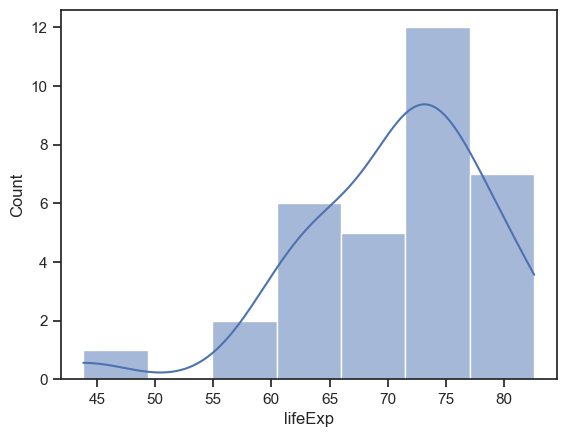

In [35]:
sns.histplot(df['lifeExp'], kde=True)

### Intervalo-Interquartil

<Axes: xlabel='continent', ylabel='lifeExp'>

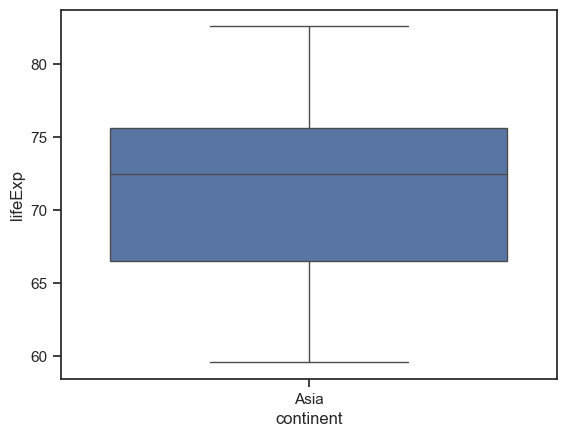

In [36]:
from numpy import percentile

q1 = df['lifeExp'].quantile(0.25)
q3 = df['lifeExp'].quantile(0.75)

iqr = q3 - q1

LI = q1 - 1.5 * iqr
LS = q3 + 1.5 * iqr


df2 = df[~((df['lifeExp'] < LI) | (df['lifeExp'] > LS))]

sns.boxplot(y='lifeExp', x='continent', data=df2)

<Axes: xlabel='lifeExp', ylabel='Count'>

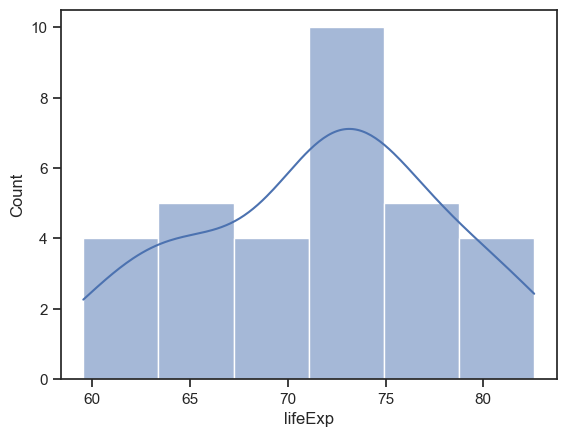

In [37]:
sns.histplot(df2['lifeExp'],kde=True)

### Z-Score

<Axes: xlabel='continent', ylabel='lifeExp'>

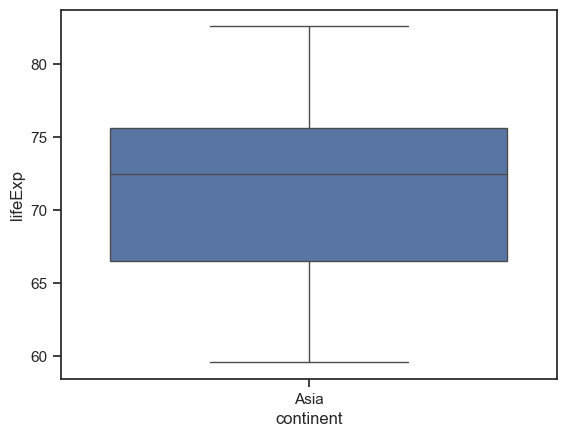

In [38]:
media = df['lifeExp'].mean()
S = df['lifeExp'].std()

Z = 2    #Z = (x — media) / S
LS = media + Z * S
LI = media - Z * S

df2 = df[~((df['lifeExp'] < LI) | (df['lifeExp'] > LS))]

sns.boxplot(y='lifeExp', x='continent', data=df2)

<Axes: xlabel='lifeExp', ylabel='Count'>

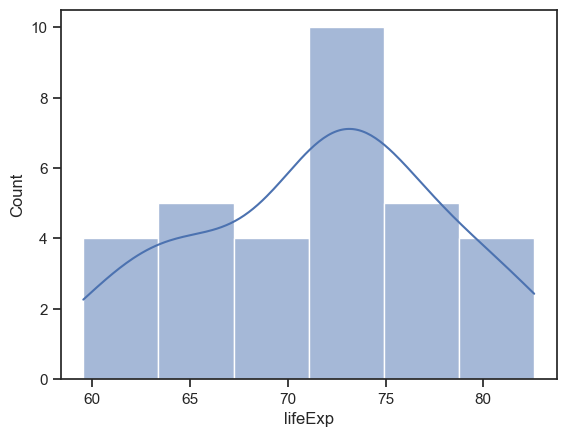

In [39]:
sns.histplot(df2['lifeExp'],kde=True)

### Padronização

<Axes: xlabel='total_bedrooms', ylabel='Count'>

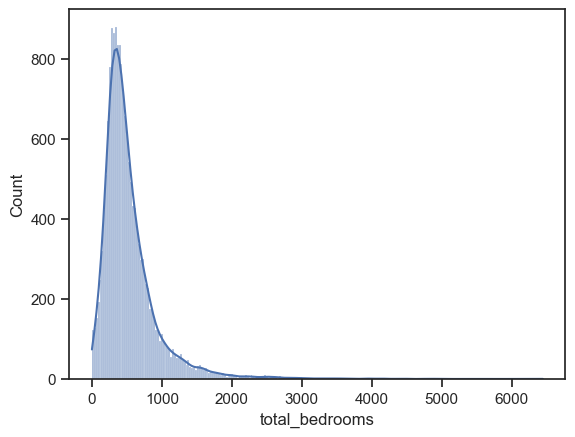

In [40]:
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("https://raw.githubusercontent.com/abaffa/INF1038/main/dataset/california_housing_train.csv")
sns.histplot(df['total_bedrooms'],kde=True)

<Axes: xlabel='total_bedrooms', ylabel='Count'>

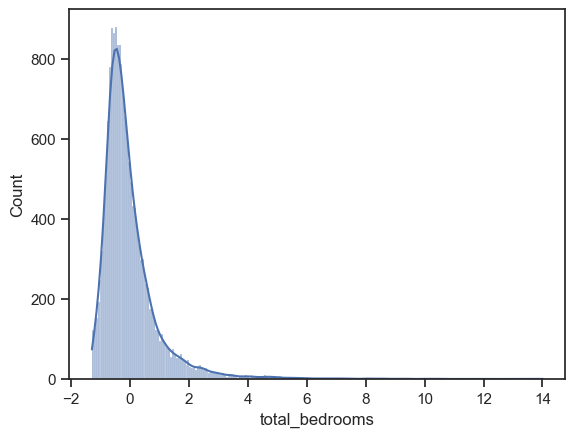

In [41]:
from sklearn import preprocessing

# x_scaled = (x — media) / S
scaler = preprocessing.StandardScaler()
scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
sns.histplot(scaled_df['total_bedrooms'],kde=True)

### Escalonamento Linear

<Axes: xlabel='total_bedrooms', ylabel='Count'>

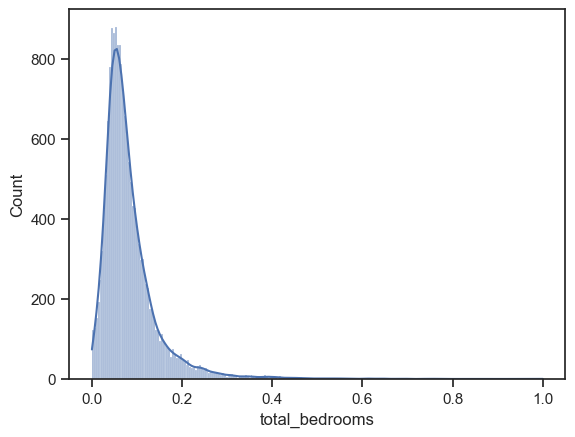

In [42]:
from sklearn import preprocessing

# x_scaled = (x-min(x)) / (max(x)–min(x))
scaler = preprocessing.MinMaxScaler()

scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
sns.histplot(scaled_df['total_bedrooms'],kde=True)

### Escalonamento Máximo

<Axes: xlabel='total_bedrooms', ylabel='Count'>

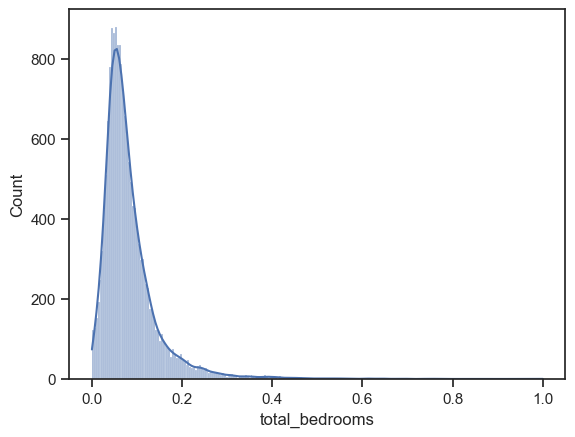

In [43]:
from sklearn import preprocessing

# x_scaled = x / max(abs(x))
scaler = preprocessing.MaxAbsScaler()

scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
sns.histplot(scaled_df['total_bedrooms'],kde=True)

### Escalonamento Robusto

<Axes: xlabel='total_bedrooms', ylabel='Count'>

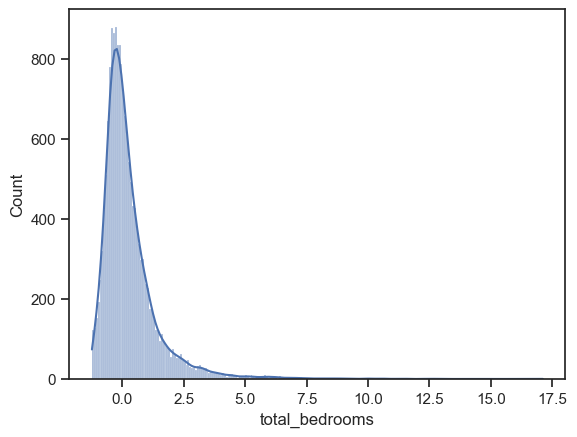

In [44]:
from sklearn import preprocessing

#(0.25,0.75) – 1o e 3o Quartis
scaler = preprocessing.RobustScaler()

scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
sns.histplot(scaled_df['total_bedrooms'],kde=True)

<Axes: xlabel='total_bedrooms', ylabel='Count'>

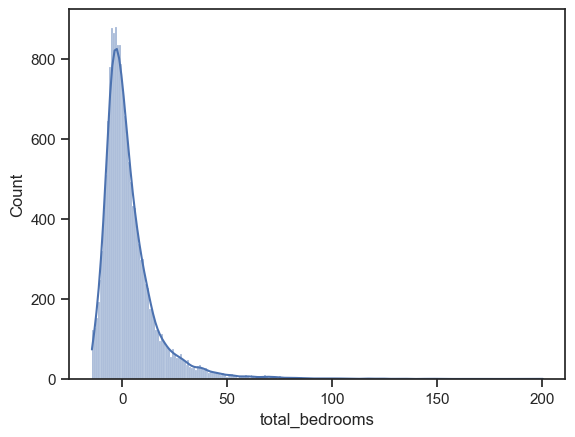

In [45]:
#(0.1,0.9) - Percentis
scaler = preprocessing.RobustScaler(
		quantile_range = (0.1,0.9))
scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
sns.histplot(scaled_df['total_bedrooms'],kde=True)

### Normalização Max

<Axes: ylabel='Count'>

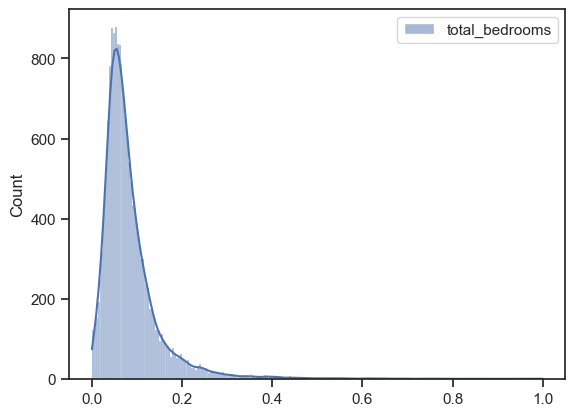

In [46]:
from sklearn import preprocessing

# x_normalized = x / max(x)
normalized_X = preprocessing.normalize([np.array(df['total_bedrooms'])], norm='max')
normalized_df = pd.DataFrame(normalized_X.T, columns=['total_bedrooms'])
sns.histplot(normalized_df,kde=True)

### Normalização L1 (Manhattan)

<Axes: ylabel='Count'>

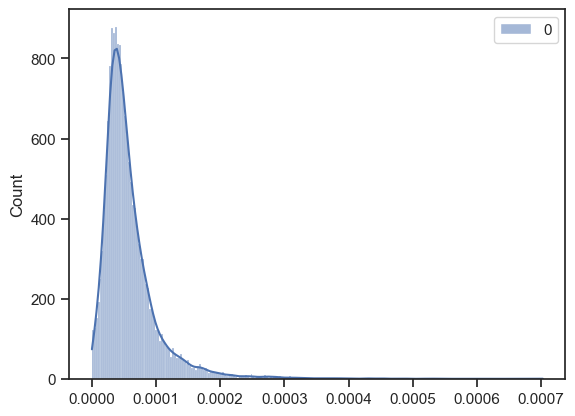

In [47]:
from sklearn import preprocessing

# x_normalized = x / sum(abs(i) for i in X)
normalized_X = preprocessing.normalize([np.array(df['total_bedrooms'])], norm='l1')
sns.histplot(normalized_X.T,kde=True)

### Normalização L2

<Axes: ylabel='Count'>

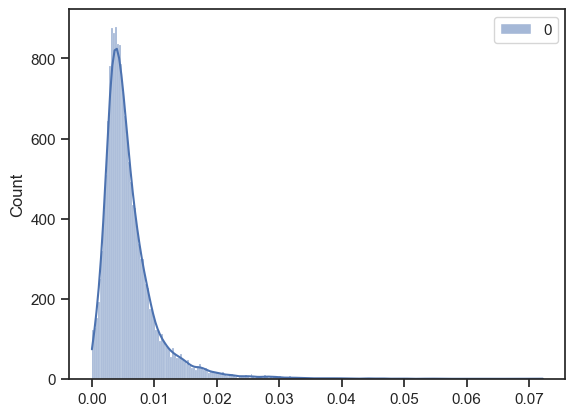

In [48]:
from sklearn import preprocessing

# x_normalized = x / sqrt(sum((i**2) for i in X))
normalized_X = preprocessing.normalize([np.array(df['total_bedrooms'])], norm='l2')
sns.histplot(normalized_X.T,kde=True)

### Assimetria positiva

<Axes: xlabel='total_bedrooms', ylabel='Count'>

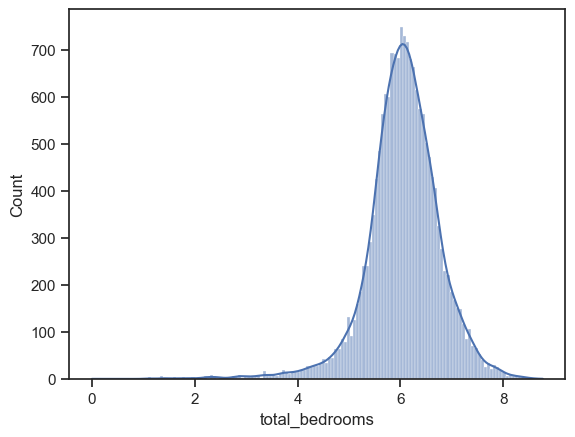

In [49]:
#C = Constante para converter o mínimo para 1
C = -df.total_bedrooms.min() + 1
total_bedrooms = np.log(df.total_bedrooms + C)
sns.histplot(total_bedrooms,kde=True)

### Assimetria negativa

<Axes: xlabel='total_bedrooms', ylabel='Count'>

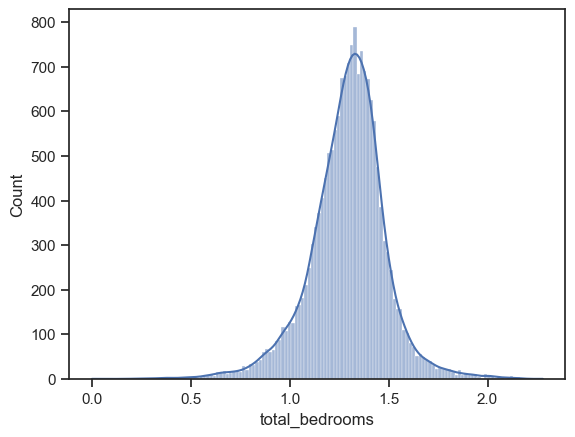

In [50]:
#K = constant para converter o máximo
#K = df.total_bedrooms.max() + 1
#total_bedrooms = np.log(K - df.total_bedrooms)

K = total_bedrooms.max() + 1
total_bedrooms = np.log(K - total_bedrooms)

sns.histplot(total_bedrooms,kde=True)

### Transformação quadrática

<Axes: xlabel='total_bedrooms', ylabel='Count'>

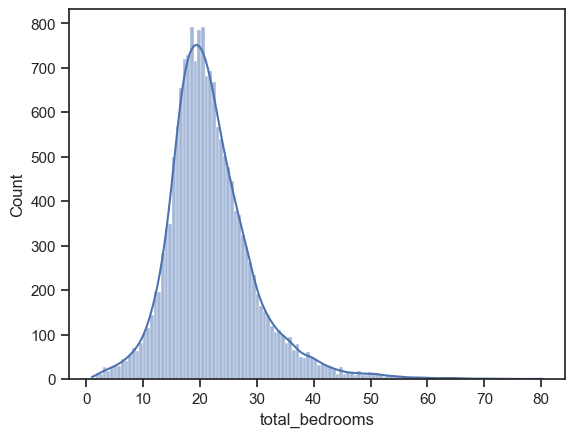

In [51]:
total_bedrooms = df.total_bedrooms **(1/2)
total_bedrooms = pd.DataFrame(total_bedrooms, columns=['total_bedrooms'])

sns.histplot(total_bedrooms['total_bedrooms'],kde=True)

Escalando a transformação:

<Axes: xlabel='total_bedrooms', ylabel='Count'>

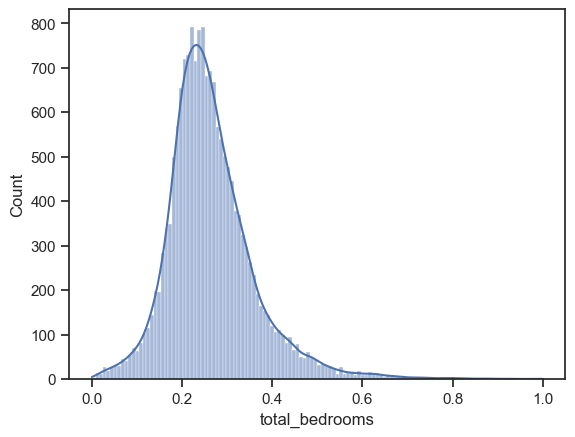

In [52]:
# x_scaled = (x-min(x)) / (max(x)–min(x))
scaler = preprocessing.MinMaxScaler()
scaled_df = scaler.fit_transform(total_bedrooms)
scaled_df = pd.DataFrame(scaled_df, columns=['total_bedrooms'])
sns.histplot(scaled_df['total_bedrooms'],kde=True)

### Transformação Cúbica

<Axes: xlabel='total_bedrooms', ylabel='Count'>

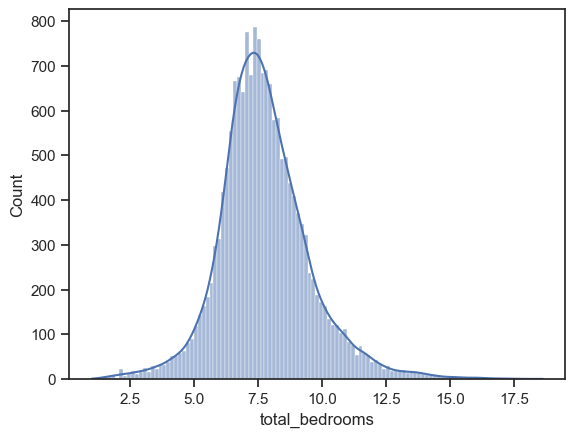

In [53]:
total_bedrooms = df.total_bedrooms **(1/3)
total_bedrooms = pd.DataFrame(total_bedrooms, columns=['total_bedrooms'])

sns.histplot(total_bedrooms['total_bedrooms'],kde=True)

Escalando a transformação:

<Axes: xlabel='total_bedrooms', ylabel='Count'>

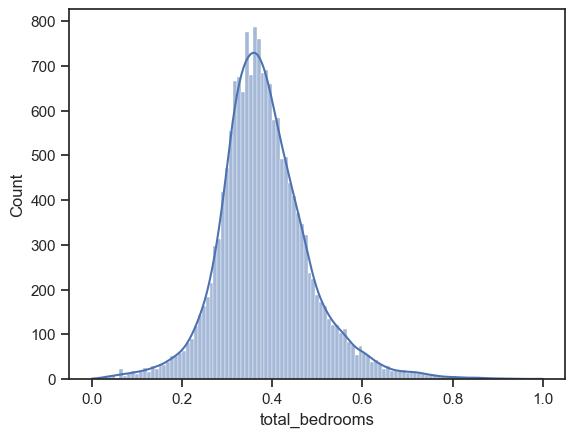

In [54]:
# x_scaled = (x-min(x)) / (max(x)–min(x))
scaler = preprocessing.MinMaxScaler()
scaled_df = scaler.fit_transform(total_bedrooms)
scaled_df = pd.DataFrame(scaled_df, columns=['total_bedrooms'])
sns.histplot(scaled_df['total_bedrooms'],kde=True)

### Transformação Log Max Root

<Axes: xlabel='total_bedrooms', ylabel='Count'>

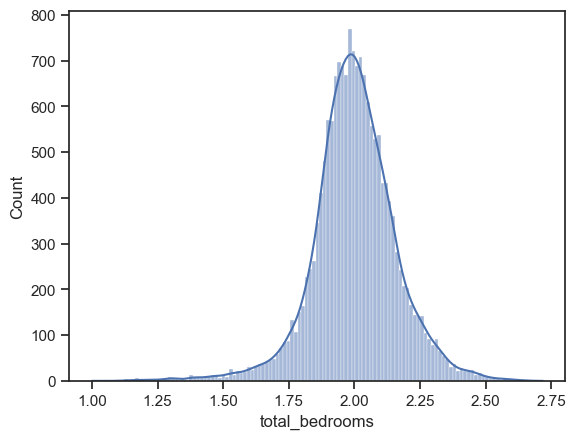

In [55]:
log_max = np.log(df.total_bedrooms.max())
total_bedrooms = df.total_bedrooms ** (1/log_max)
total_bedrooms = pd.DataFrame(total_bedrooms, columns=['total_bedrooms'])

sns.histplot(total_bedrooms['total_bedrooms'],kde=True)

Escalando a transformação:

<Axes: xlabel='total_bedrooms', ylabel='Count'>

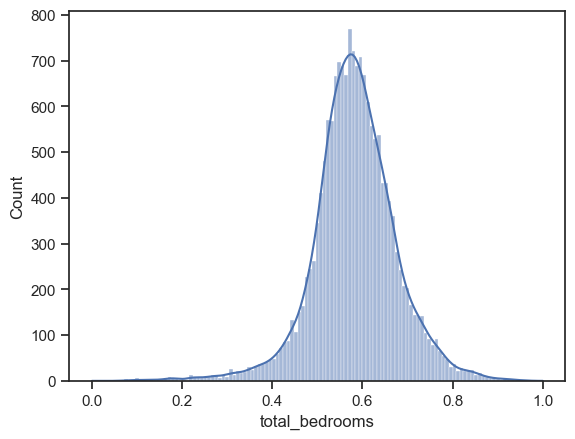

In [56]:
# x_scaled = (x-min(x)) / (max(x)–min(x))
scaler = preprocessing.MinMaxScaler()
scaled_df = scaler.fit_transform(total_bedrooms)
scaled_df = pd.DataFrame(scaled_df, columns=['total_bedrooms'])
sns.histplot(scaled_df['total_bedrooms'],kde=True)

### Transformação logarítmica

<Axes: xlabel='total_bedrooms', ylabel='Count'>

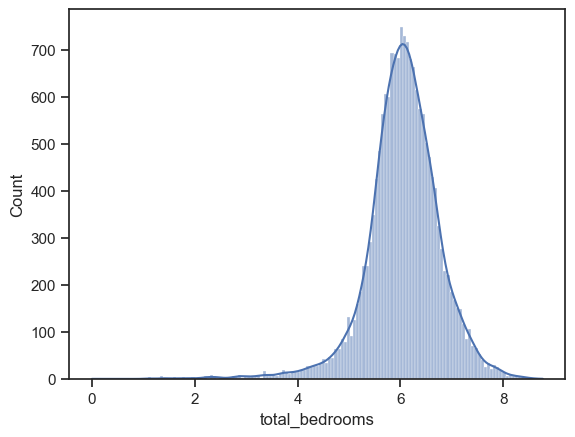

In [57]:
total_bedrooms = np.log(df.total_bedrooms)
total_bedrooms = pd.DataFrame(total_bedrooms, columns=['total_bedrooms'])

sns.histplot(total_bedrooms['total_bedrooms'],kde=True)

Ao final podemos escalar o resultado
* Isto facilita a comparação entre as distribuições

<Axes: xlabel='total_bedrooms', ylabel='Count'>

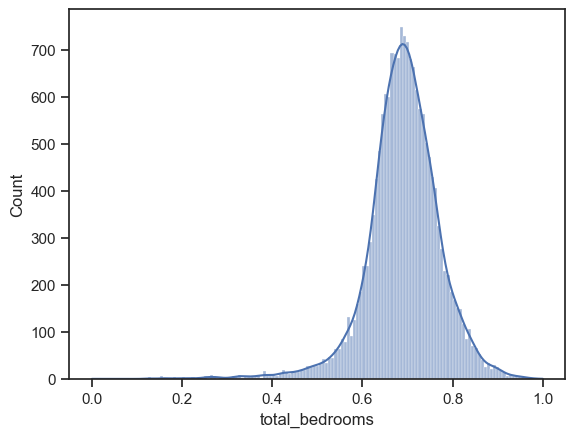

In [58]:
# x_scaled = (x-min(x)) / (max(x)–min(x))
scaler = preprocessing.MinMaxScaler()

scaled_df = scaler.fit_transform(total_bedrooms)
scaled_df = pd.DataFrame(scaled_df, columns=['total_bedrooms'])
sns.histplot(scaled_df['total_bedrooms'],kde=True)

### Transformação Log + 1

<Axes: xlabel='total_bedrooms', ylabel='Count'>

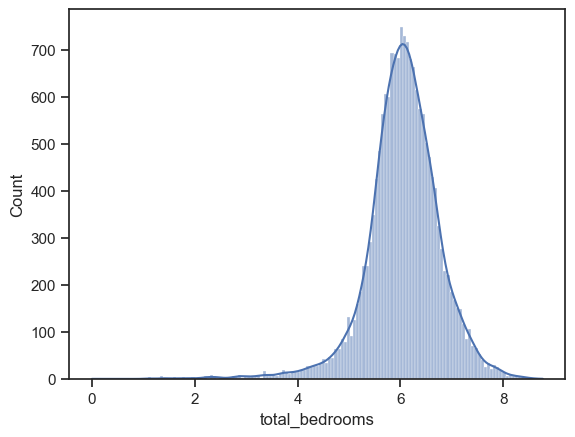

In [59]:
C = -df.total_bedrooms.min() + 1

#np.log1p(x)
total_bedrooms = np.log(df.total_bedrooms + C)
total_bedrooms = pd.DataFrame(total_bedrooms, columns=['total_bedrooms'])
sns.histplot(total_bedrooms['total_bedrooms'],kde=True)

Escalando a transformação:

<Axes: xlabel='total_bedrooms', ylabel='Count'>

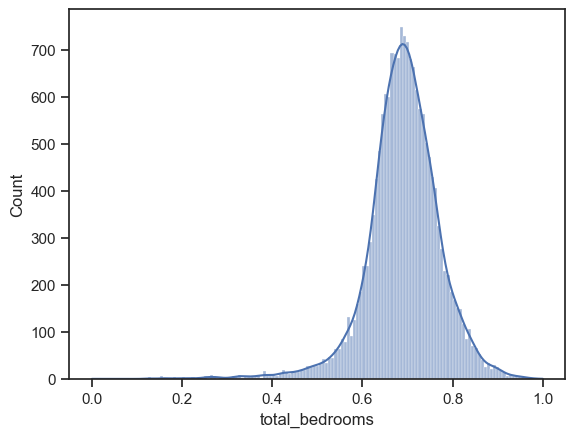

In [60]:
# x_scaled = (x-min(x)) / (max(x)–min(x))
scaler = preprocessing.MinMaxScaler()

scaled_df = scaler.fit_transform(total_bedrooms)
scaled_df = pd.DataFrame(scaled_df, columns=['total_bedrooms'])
sns.histplot(scaled_df['total_bedrooms'],kde=True)

Para distribuições com assimetria negativa usamos 1-Log ou K-Log:

<Axes: xlabel='total_bedrooms', ylabel='Count'>

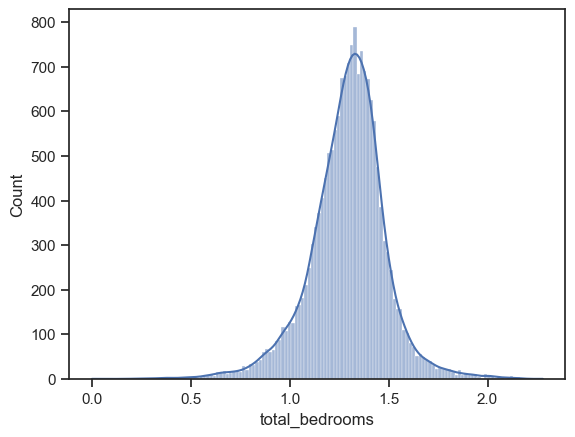

In [61]:
# Transformando a distribuição em uma distribuição com assimetria negativa
C = -df.total_bedrooms.min() + 1
total_bedrooms = np.log(df.total_bedrooms + C)

# Aplicando o Log + 1 em uma distribuição com assimetria negativa
K = total_bedrooms.max() +1

total_bedrooms = np.log(K - total_bedrooms)
total_bedrooms = pd.DataFrame(total_bedrooms, columns=['total_bedrooms'])
sns.histplot(total_bedrooms['total_bedrooms'],kde=True)

Escalando a transformação:

<Axes: xlabel='total_bedrooms', ylabel='Count'>

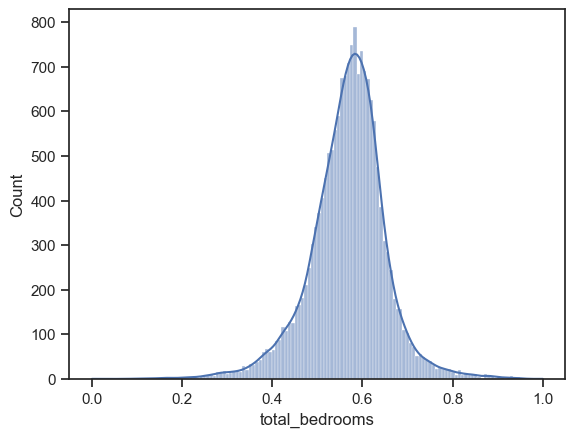

In [62]:
# x_scaled = (x-min(x)) / (max(x)–min(x))
scaler = preprocessing.MinMaxScaler()

scaled_df = scaler.fit_transform(total_bedrooms)
scaled_df = pd.DataFrame(scaled_df, columns=['total_bedrooms'])
sns.histplot(scaled_df['total_bedrooms'],kde=True)

### Métodos p/ Préprocessamento

PowerTransformer

Aplica uma transformação de potência, característica por característica, para tornar os dados mais semelhantes a uma distribuição gaussiana.

As transformações de potência são uma família de transformações paramétricas e monotônicas aplicadas para tornar os dados mais semelhantes a uma distribuição gaussiana. Isso é útil para modelar problemas relacionados à heterocedasticidade (variância não constante) ou outras situações em que a normalidade é desejada.

Suporta a transformada de Box-Cox e a transformada de Yeo-Johnson. O parâmetro ideal para estabilizar a variância e minimizar a assimetria é estimado por meio da máxima verossimilhança.

O teste Box-Cox exige que os dados de entrada sejam estritamente positivos, enquanto o teste Yeo-Johnson aceita tanto dados positivos quanto negativos.

In [77]:
from sklearn.preprocessing import PowerTransformer

df_pt = df[['total_bedrooms']].copy()

pt = PowerTransformer(
    method='yeo-johnson',
    standardize=True
)
#‘yeo-johnson’ valores positivos e negativos
#‘box-cox’ apenas valores positivos

df_pt['total_bedrooms_transf'] = pt.fit_transform(
    df_pt[['total_bedrooms']]
)

df_pt.head()

KeyError: "None of [Index(['total_bedrooms'], dtype='object')] are in the [columns]"

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    df_pt['total_bedrooms'],
    kde=True,
    ax=ax[0]
)
ax[0].set_title('Total Bedrooms')
ax[0].set_xlabel('Total Bedrooms')

sns.histplot(
    df_pt['total_bedrooms_transf'],
    kde=True,
    ax=ax[1]
)
ax[1].set_title('Após PowerTransformer')
ax[1].set_xlabel('TotalBedrooms transformado')

plt.show()

Quantile Transformer

Este método transforma as características para seguirem uma distribuição uniforme ou normal. Portanto, para uma determinada característica, essa transformação tende a dispersar os valores mais frequentes. Também reduz o impacto de outliers (marginais): trata-se, portanto, de um esquema de pré-processamento robusto.

In [ ]:
from sklearn.preprocessing import QuantileTransformer

df_qt = df[['total_bedrooms']].copy()

qt = QuantileTransformer(
    output_distribution='normal',
    random_state=42
)

df_qt['total_bedrooms_transf'] = qt.fit_transform(
    df_qt[['total_bedrooms']]
)

df_qt.head()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    df_qt['total_bedrooms'],
    kde=True,
    ax=ax[0]
)
ax[0].set_title('Total Bedrooms')
ax[0].set_xlabel('Total Bedrooms')

sns.histplot(
    df_qt['total_bedrooms_transf'],
    kde=True,
    ax=ax[1]
)
ax[1].set_title('Após QuantileTransformer')
ax[1].set_xlabel('TotalBedrooms transformado')

plt.show()

### Transformação Linearização do Percentil

In [ ]:
size = len(df.total_bedrooms)-1
total_bedrooms = df.total_bedrooms.rank(method='min').apply(lambda x: (x-1)/size)
total_bedrooms = pd.DataFrame(total_bedrooms, columns=['total_bedrooms'])

sns.histplot(total_bedrooms['total_bedrooms'],kde=True)

### Transformação Linearização do Percentil

In [ ]:
size = len(df.housing_median_age)-1
housing_median_age = df.housing_median_age.rank(method='min').apply(lambda x: (x-1)/size)
housing_median_age = pd.DataFrame(housing_median_age, columns=['housing_median_age'])

sns.histplot(housing_median_age['housing_median_age'],kde=True)

# Transformação numérico em categórico

### Mapeamento direto

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

labels = [["F","M"]]
encoder = OrdinalEncoder(categories=labels)
encoder.fit(np.array(labels).reshape(-1, 1).tolist())
encoder.inverse_transform([[1],[0],[0],[1]])

In [ ]:
labels = [["ruim", "mediano", "bom"]]
encoder = OrdinalEncoder(categories=labels)
encoder.fit(np.array(labels).reshape(-1, 1).tolist())
encoder.inverse_transform([[2],[0],[0],[1]])

### Mapeamento em intervalos (discretização)

In [ ]:
df_idade = pd.DataFrame({'idade': np.random.randint(21, 51, 8)})
df_idade['idade_faixas'] = pd.cut(x=df_idade['idade'], bins=[19, 29, 39, 49, 59])
df_idade['idade_decada'] = pd.cut(x=df_idade['idade'], bins=[19, 29, 39, 49, 59], labels=['20s', '30s', '40s', '50s'])
df_idade

# Transformação categórico em numérico

### Mapeamento direto

In [ ]:
df_estado_civil = pd.DataFrame({'Estado Civil': ["Casado","Solteiro","Solteiro", "Casado", "Viúvo", "Divorciado","Outro"]})

encoder = OrdinalEncoder()

df_estado_civil['Mapeamento'] = encoder.fit_transform(df_estado_civil["Estado Civil"].values.reshape(-1, 1))
df_estado_civil

In [ ]:
labels = [["ruim", "regular", "bom", "ótimo"]]

df_conceito = pd.DataFrame({'Conceito': ["bom", "ruim", "ruim", "ótimo", "regular"]})

encoder = OrdinalEncoder(categories=labels)
encoder.fit(np.array(labels).reshape(-1, 1).tolist())
df_conceito['Mapeamento'] = encoder.fit_transform(df_conceito["Conceito"].values.reshape(-1, 1))
df_conceito

In [ ]:
from sklearn.preprocessing import LabelEncoder
labels = [["ruim", "regular", "bom", "ótimo"]]

df_conceito = pd.DataFrame({'Conceito': ["bom", "ruim", "ruim", "ótimo", "regular"]})

encoder = LabelEncoder()
encoder.fit(np.array(labels).reshape(-1, 1).tolist())
df_conceito['Mapeamento'] = encoder.fit_transform(df_conceito["Conceito"].values)
df_conceito

### Representação binária 1-de-N (Classes)

In [ ]:
df_estado_civil = pd.DataFrame({'Estado Civil': ["Casado","Solteiro","Solteiro", "Casado", "Viúvo", "Divorciado","Outro"]})

from sklearn.preprocessing import LabelBinarizer

labelBin = LabelBinarizer()
labelBin.fit_transform(df_estado_civil['Estado Civil'])

### Representação binária N-de-N (Atributos)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

X = pd.DataFrame(
    np.array(['M', 'O-', 'Média',
              'M', 'O-', 'Alta',
              'F', 'O+', 'Alta',
              'F', 'AB', 'Baixa',
              'F', 'B+', np.NaN]).reshape((5,3)),
                columns = ['Sexo', 'Tipo Sangue', 'Educação'])

onehot = OneHotEncoder(dtype=int)
nominals = pd.DataFrame(onehot.fit_transform(X[['Sexo', 'Tipo Sangue']]).toarray(),
					    columns=['F', 'M', 'AB', 'B+','O+', 'O-'])
nominals['Educação'] = X.Educação
X

In [ ]:
nominals

# Comparando Boxplot

Escalando as variáveis do dataset “expectativa.csv”:

In [ ]:
from sklearn import preprocessing

columns = ['year', 'pop', 'lifeExp','gdpPercap']
df = pd.DataFrame(data[columns], columns=columns)

scaler = preprocessing.MinMaxScaler()
scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df

Boxplot Original:

In [ ]:
import seaborn as sns
f, ax = plt.subplots(figsize=(100, 8))
bp = sns.boxplot(data=data, width=0.5, palette="colorblind")
plt.setp(bp.get_xticklabels(), rotation=90)
bp.tick_params(labelsize=80)

Boxplot Escalado:

In [ ]:
import seaborn as sns
f, ax = plt.subplots(figsize=(100, 8))
bp = sns.boxplot(data=scaled_df, width=0.5, palette="colorblind")
plt.setp(bp.get_xticklabels(), rotation=90)
bp.tick_params(labelsize=80)

Boxplot sem outliers e Escalado:

In [ ]:
from numpy import percentile

columns = ['year', 'pop', 'lifeExp','gdpPercap']
df = pd.DataFrame(data[columns], columns=columns)

def removeOutlier(df, col):
    quartis = percentile(df[col], [25, 75])
    d = quartis[1] - quartis[0]
    media = data[col].mean()
    LS = media + 1.5 * d
    LI = media - 1.5 * d

    return df[~((df[col] < LI) | (df[col] > LS))]

df = removeOutlier(df, 'pop')
df = removeOutlier(df, 'lifeExp')
df = removeOutlier(df, 'gdpPercap')

scaler = preprocessing.MinMaxScaler()
scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)

In [ ]:
import seaborn as sns
f, ax = plt.subplots(figsize=(100, 8))
bp = sns.boxplot(data=scaled_df, width=0.5, palette="colorblind")
plt.setp(bp.get_xticklabels(), rotation=90)
bp.tick_params(labelsize=80)

### Comparando Ternário

In [ ]:
df = data[data.year == 2007]

label_pre = data["continent"].unique().tolist()

points = []
for label in label_pre:
    mask = df['continent'] == label
    pos = np.flatnonzero(mask)
    dataf = df.iloc[pos]
    endmembers = ['gdpPercap','pop','lifeExp']
    points_ = dataf[endmembers].values
    points.append(points_)

colors = ['orange', 'yellowgreen', 'green','red', 'blue']
plot_ternario("Pop x lifeExp x gdpPerCap",label_pre,points,colors,endmembers)

Ternário Escalado

In [ ]:
from numpy import percentile

columns = ['year', 'pop', 'lifeExp','gdpPercap']
df2 = data[data.year == 2007]
df = pd.DataFrame(df2, columns=df2.columns)

# x_scaled = (x-min(x)) / (max(x)–min(x))
scaler = preprocessing.MinMaxScaler(feature_range=(0,100))
scaled_df = scaler.fit_transform(df[columns])
scaled_df = pd.DataFrame(scaled_df, columns=columns, index = df.index)
scaled_df["continent"] = df["continent"]

label_pre = scaled_df["continent"].unique().tolist()

points = []
for label in label_pre:
    mask = scaled_df['continent'] == label
    pos = np.flatnonzero(mask)
    dataf = scaled_df.iloc[pos]
    endmembers = ['gdpPercap','pop','lifeExp']
    points_ = dataf[endmembers].values
    points.append(points_)

colors = ['orange', 'yellowgreen', 'green','red', 'blue']
plot_ternario("Pop x lifeExp x gdpPerCap",label_pre,points,colors,endmembers)

Ternário sem outliers e Escalado

In [ ]:
from numpy import percentile

columns = ['year', 'pop', 'lifeExp','gdpPercap']
df2 = data[data.year == 2007]
df = pd.DataFrame(df2, columns=df2.columns)

def removeOutlier(df, col):
    quartis = percentile(df[col], [25, 75])
    d = quartis[1] - quartis[0]
    media = data[col].mean()
    LS = media + 1.5 * d
    LI = media - 1.5 * d

    return df[~((df[col] < LI) | (df[col] > LS))]

df = removeOutlier(df, 'pop')
df = removeOutlier(df, 'lifeExp')
df = removeOutlier(df, 'gdpPercap')


# x_scaled = (x-min(x)) / (max(x)–min(x))
scaler = preprocessing.MinMaxScaler(feature_range=(0,100))
scaled_df = scaler.fit_transform(df[columns])
scaled_df = pd.DataFrame(scaled_df, columns=columns, index = df.index)
scaled_df["continent"] = df["continent"]

label_pre = scaled_df["continent"].unique().tolist()

points = []
for label in label_pre:
    mask = scaled_df['continent'] == label
    pos = np.flatnonzero(mask)
    dataf = scaled_df.iloc[pos]
    endmembers = ['gdpPercap','pop','lifeExp']
    points_ = dataf[endmembers].values
    points.append(points_)

colors = ['orange', 'yellowgreen', 'green','red', 'blue']
plot_ternario("Pop x lifeExp x gdpPerCap",label_pre,points,colors,endmembers)

# Realizando a Análise Exploratória

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
data = pd.read_csv("https://raw.githubusercontent.com/abaffa/INF1038/main/dataset/wine.csv")

In [65]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Class,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity of ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


### Analisando Boxplot

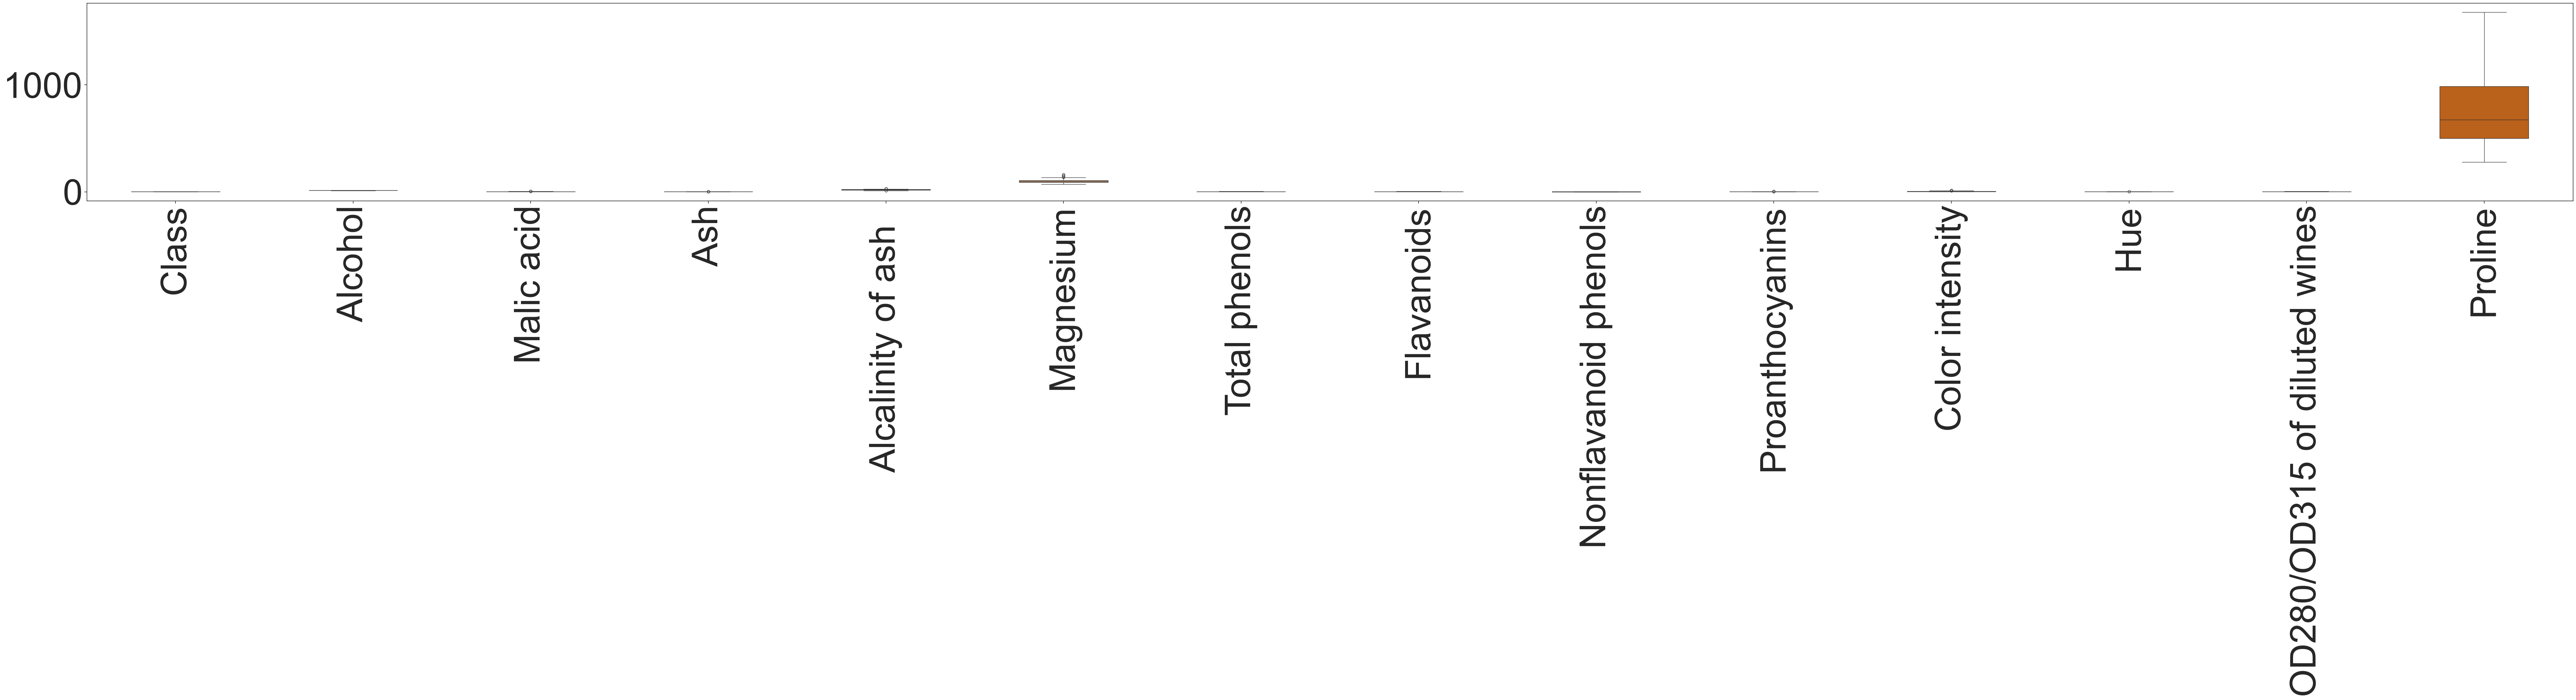

In [66]:
df = data

f, ax = plt.subplots(figsize=(100, 8))
bp = sns.boxplot(data=df, width=0.5, palette="colorblind")
plt.setp(bp.get_xticklabels(), rotation=90)
bp.tick_params(labelsize=80)

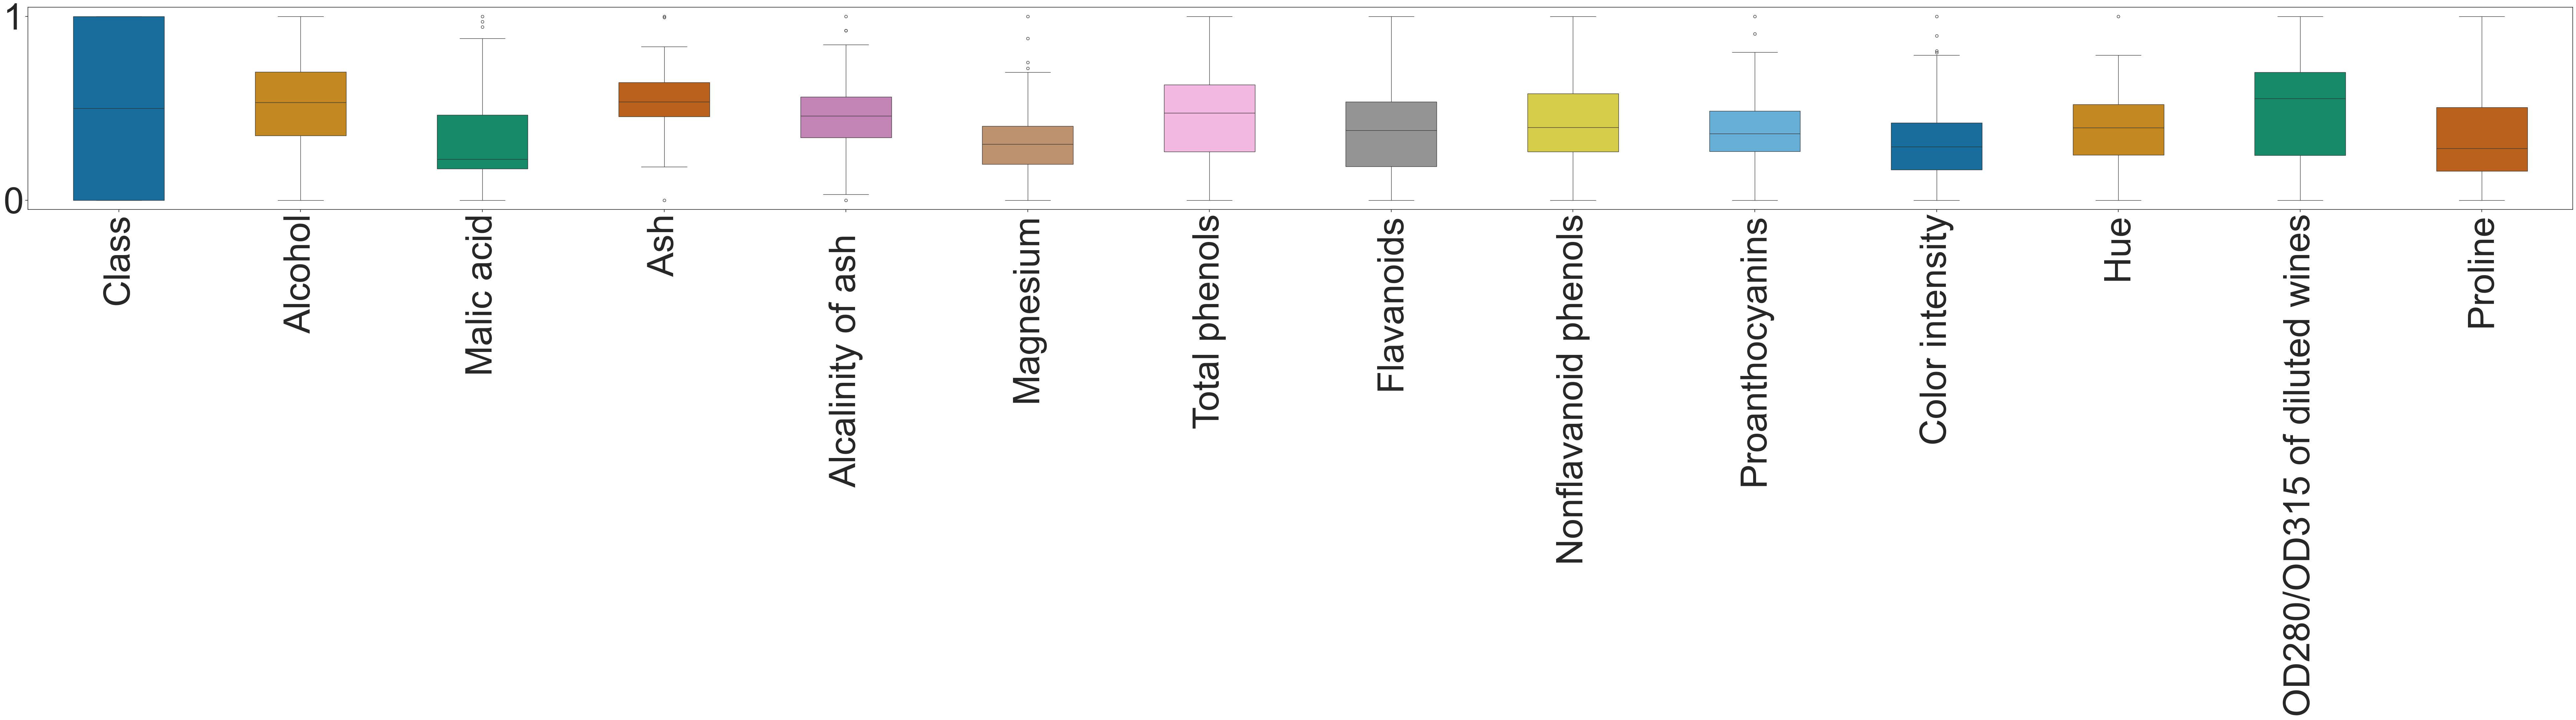

In [67]:
df = pd.DataFrame(data, columns=data.columns)

scaler = preprocessing.MinMaxScaler()
scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)

f, ax = plt.subplots(figsize=(100, 8))
bp = sns.boxplot(data=scaled_df, width=0.5, palette="colorblind")
plt.setp(bp.get_xticklabels(), rotation=90)
bp.tick_params(labelsize=80)

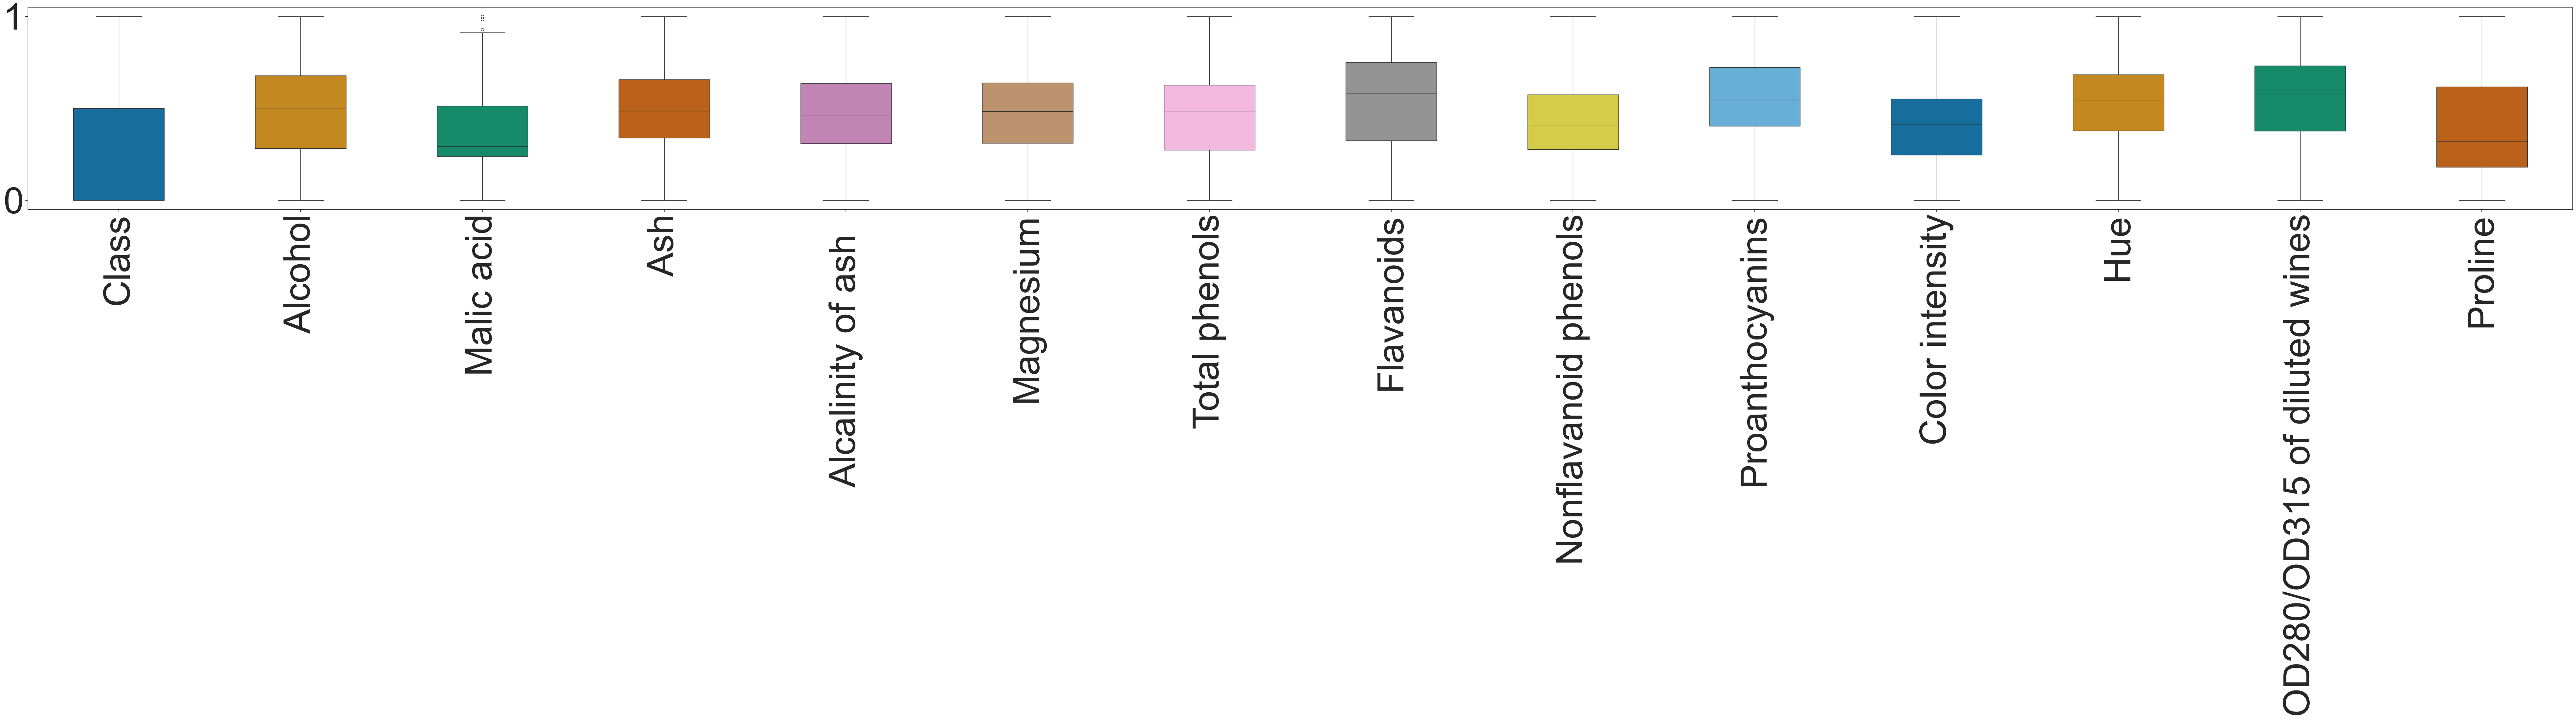

In [68]:
from numpy import percentile

df = pd.DataFrame(data, columns=data.columns)

def removeOutlier(df, col):
    quartis = percentile(df[col], [25, 75])
    d = quartis[1] - quartis[0]
    media = data[col].mean()
    LS = media + 1.5 * d
    LI = media - 1.5 * d

    return df[~((df[col] < LI) | (df[col] > LS))]

for c in data.columns:
    if c != 'Class':
        df = removeOutlier(df, c)

scaler = preprocessing.MinMaxScaler()
scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)

f, ax = plt.subplots(figsize=(100, 8))
bp = sns.boxplot(data=scaled_df, width=0.5, palette="colorblind")
plt.setp(bp.get_xticklabels(), rotation=90)
bp.tick_params(labelsize=80)

### Matriz de Correlação

In [69]:
df = data.apply(lambda row: pd.Series({'Type': 'Type ' + str(row['Class'])}), axis=1)
df = pd.merge(df, data, left_index=True, right_index=True)

<Axes: >

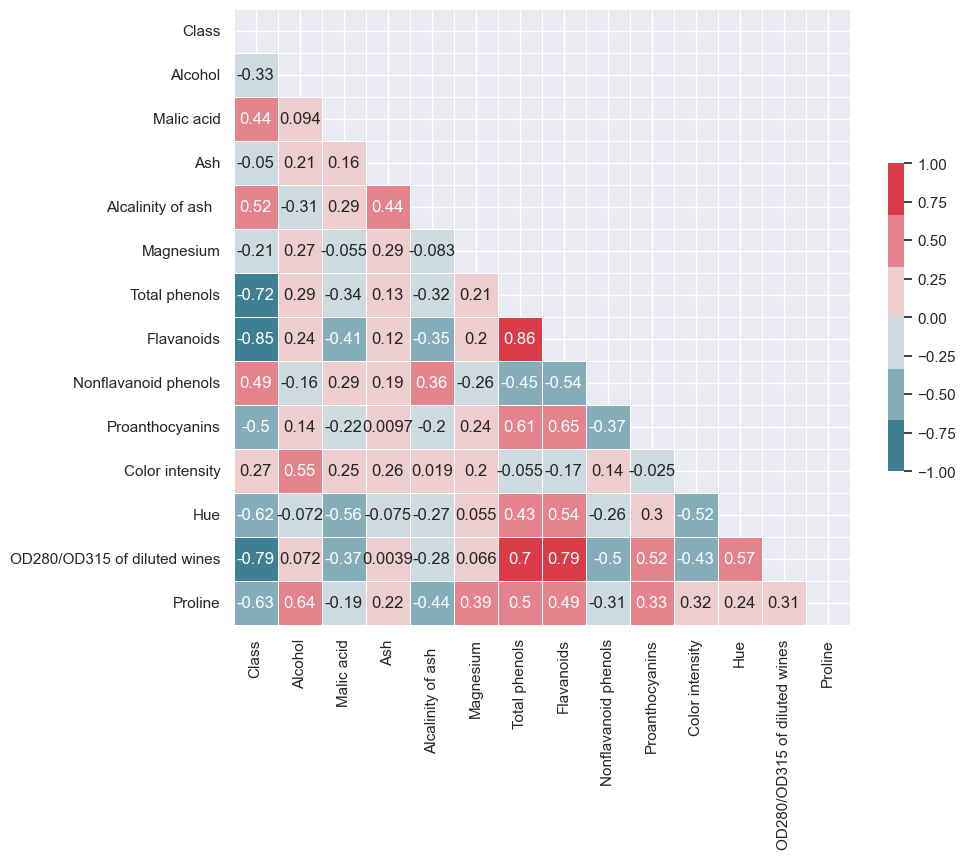

In [70]:
corr = df.corr(numeric_only=True)

sns.set(style="darkgrid")

f, ax = plt.subplots(figsize=(10, 8))

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)]=True

cmap = sns.diverging_palette(220, 10)

sns.heatmap(corr, mask=mask, annot=True, cmap=cmap,
            vmax=1, vmin=-1, center=0, square=True,
            linewidth=.5,cbar_kws={"shrink":.5})

### Pairplot

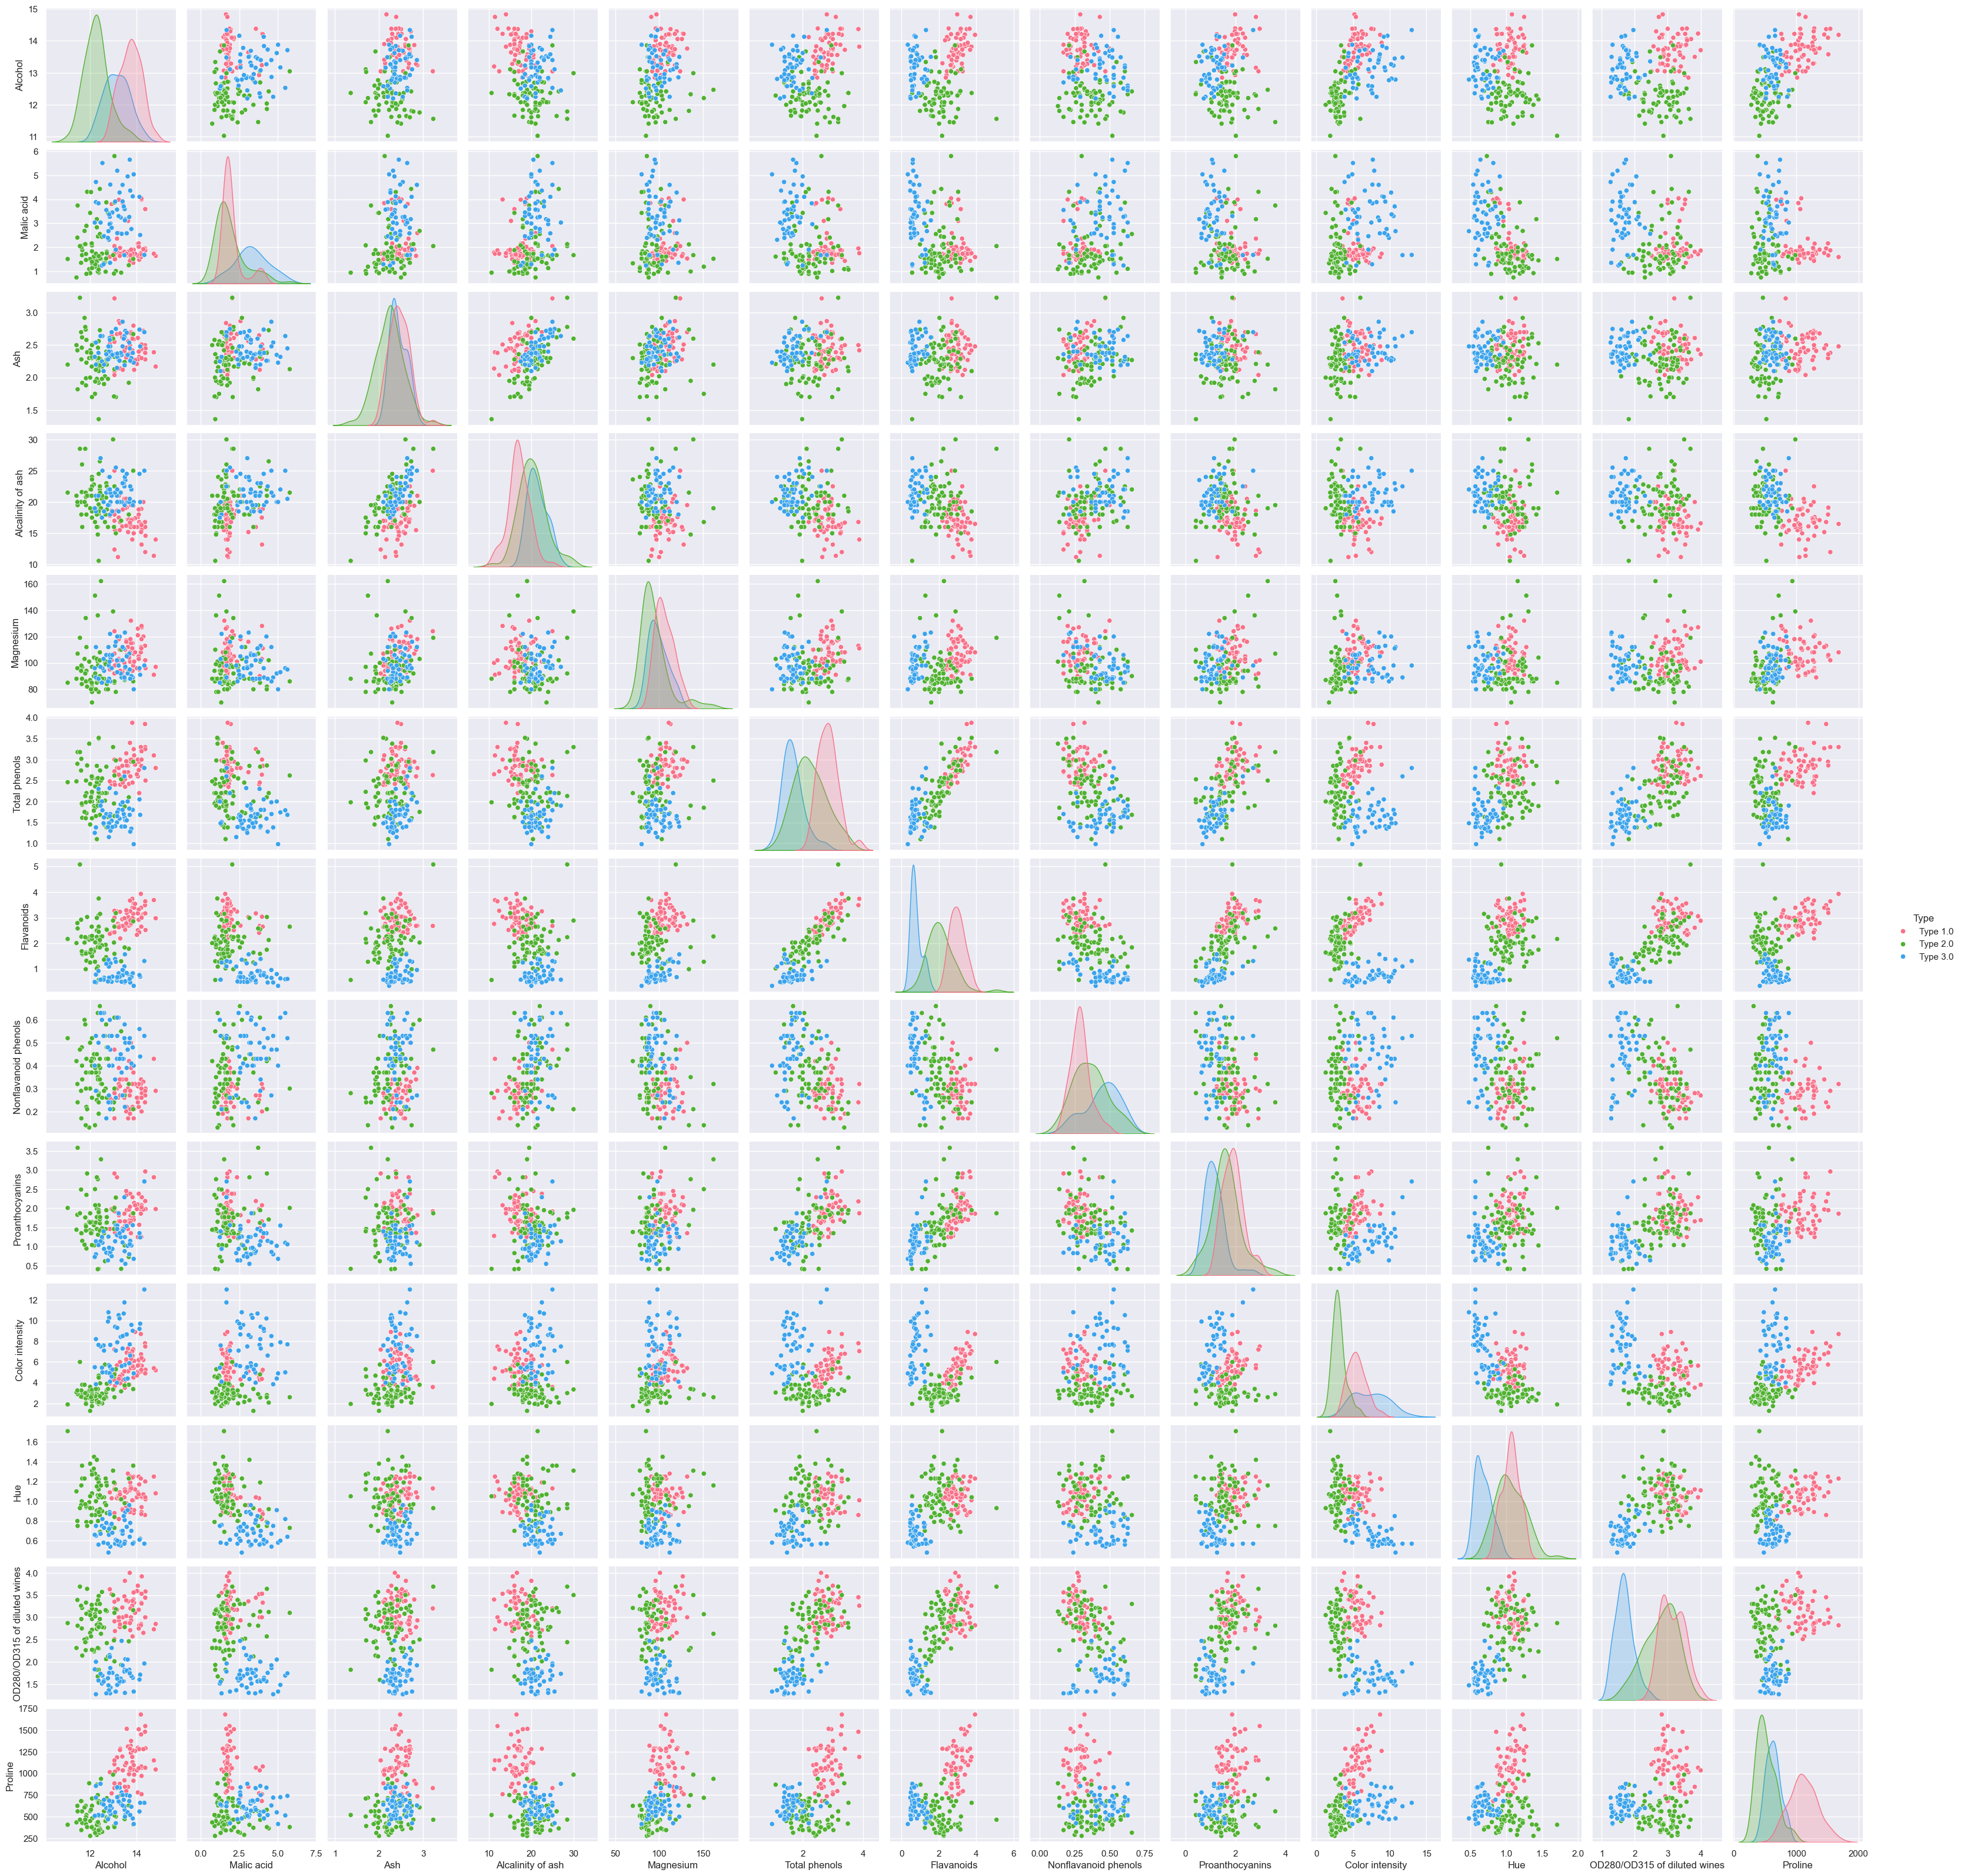

In [76]:
df = df.drop(['Class'], axis=1)
sns.pairplot(df, hue="Type", palette="husl")

### Comparando Ternário

Ternário Original

D:\Backup\OneDrive - puc-rio.br\Jupyter\venv\lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


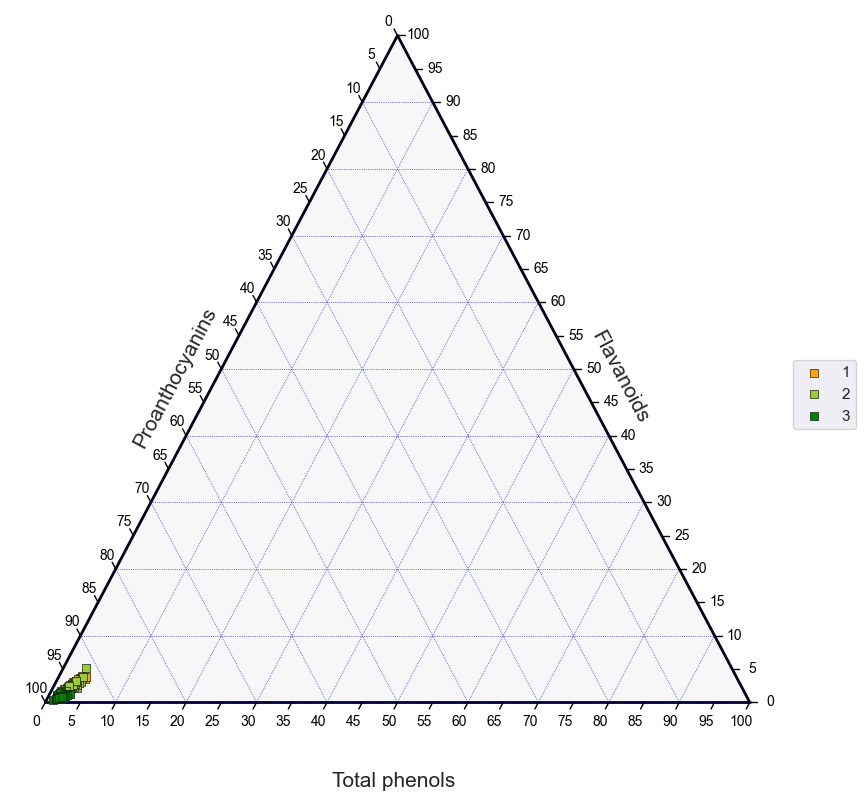

In [86]:
datafl = data

label_pre = datafl["Class"].unique().tolist()

points = []
for label in label_pre:
    mask = datafl['Class'] == label
    pos = np.flatnonzero(mask)
    df = datafl.iloc[pos]
    endmembers = ['Total phenols','Flavanoids', 'Proanthocyanins']
    points_ = df[endmembers].values
    points.append(points_)

colors = ['orange', 'yellowgreen', 'green','orange', 'yellowgreen', 'green','orange', 'yellowgreen', 'green']
plot_ternario("",label_pre,points,colors,endmembers)

Ternário Escalado

D:\Backup\OneDrive - puc-rio.br\Jupyter\venv\lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


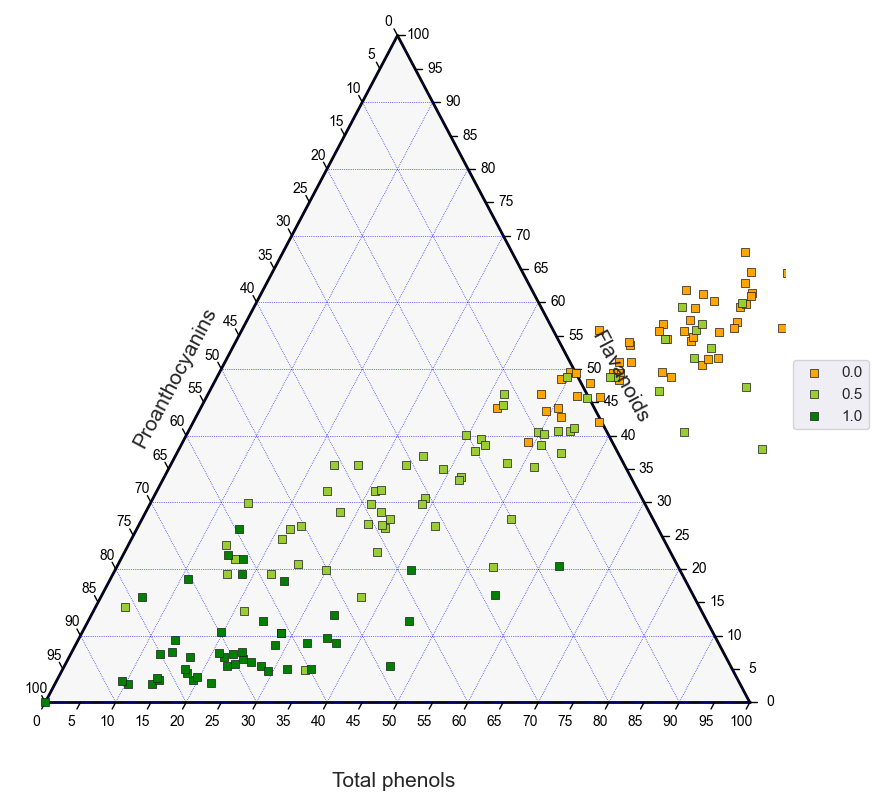

In [87]:
df = pd.DataFrame(data, columns=data.columns)

scaler = preprocessing.MinMaxScaler()
scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)

datafl = scaled_df
datafl['Total phenols'] = datafl['Total phenols'] * 100
datafl['Flavanoids'] = datafl['Flavanoids'] * 100
datafl['Proanthocyanins'] = datafl['Proanthocyanins'] * 100

label_pre = datafl["Class"].unique().tolist()

points = []
for label in label_pre:
    mask = datafl['Class'] == label
    pos = np.flatnonzero(mask)
    df = datafl.iloc[pos]
    endmembers = ['Total phenols','Flavanoids', 'Proanthocyanins']
    points_ = df[endmembers].values
    points.append(points_)

colors = ['orange', 'yellowgreen', 'green','orange', 'yellowgreen', 'green','orange', 'yellowgreen', 'green']
plot_ternario("",label_pre,points,colors,endmembers)

Ternário sem outliers e escalado

D:\Backup\OneDrive - puc-rio.br\Jupyter\venv\lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


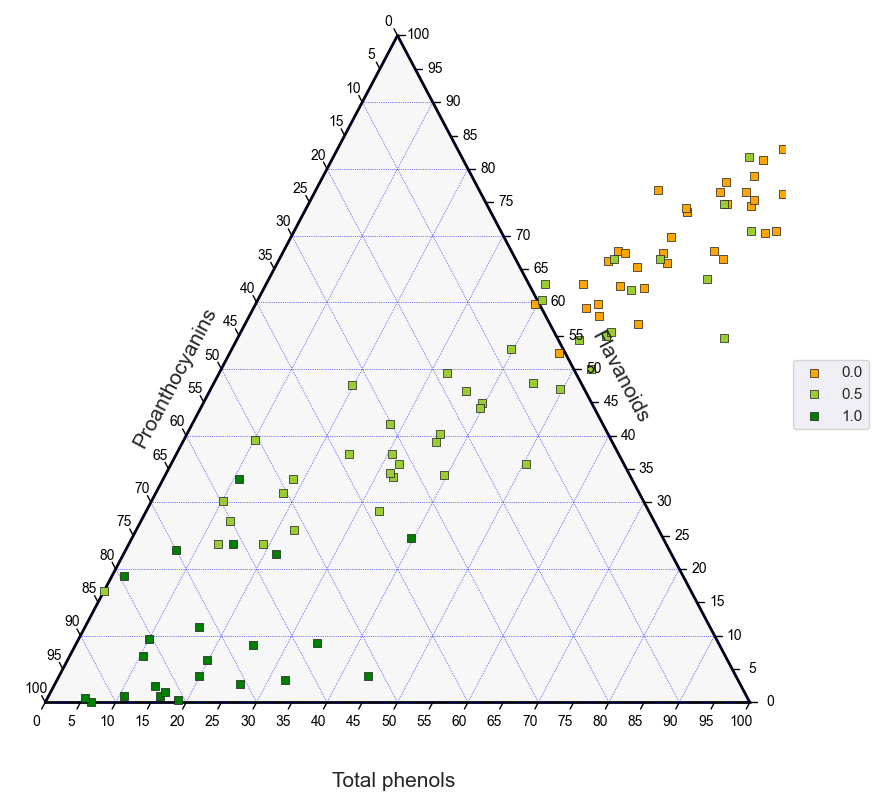

In [88]:
df = pd.DataFrame(data, columns=data.columns)

def removeOutlier(df, col):
    quartis = percentile(df[col], [25, 75])
    d = quartis[1] - quartis[0]
    media = data[col].mean()
    LS = media + 1.5 * d
    LI = media - 1.5 * d

    return df[~((df[col] < LI) | (df[col] > LS))]

for c in data.columns:
    if c != 'Class':
        df = removeOutlier(df, c)

scaler = preprocessing.MinMaxScaler()
scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)

datafl = scaled_df
datafl['Total phenols'] = datafl['Total phenols'] * 100
datafl['Flavanoids'] = datafl['Flavanoids'] * 100
datafl['Proanthocyanins'] = datafl['Proanthocyanins'] * 100

label_pre = datafl["Class"].unique().tolist()

points = []
for label in label_pre:
    mask = datafl['Class'] == label
    pos = np.flatnonzero(mask)
    df = datafl.iloc[pos]
    endmembers = ['Total phenols','Flavanoids', 'Proanthocyanins']
    points_ = df[endmembers].values
    points.append(points_)

colors = ['orange', 'yellowgreen', 'green','orange', 'yellowgreen', 'green','orange', 'yellowgreen', 'green']
plot_ternario("",label_pre,points,colors,endmembers)